Проект сделан на основе выработанного шаблона:
- https://github.com/evgeny-ydsc/first-project/blob/main/шаблон%20проекта/шаблон%20проекта.ipynb

# Проект Телеком

# Постановка задачи

Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи. Чтобы заранее находить таких пользователей, «ТелеДому» нужна модель, которая будет предсказывать, разорвёт ли абонент договор. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и услугах. Ваша **задача — обучить** на этих данных **модель для прогноза оттока клиентов**.

## Критерии успеха
- Значение метрики **ROC-AUC** должно быть **не менее 0.85**.

Для интерпретируемости модели дополнительно выведите значение **accuracy**.

<div class="alert alert-secondary" style="background-color:#D9EEE1;color:black;">

## Описание данных

Описание данных

Данные хранятся в Sqlite  — СУБД, в которой база данных представлена одним файлом. Она состоит из нескольких таблиц:

- **contract** — информация о договорах;
- **personal** — персональные данные клиентов;
- **internet** — информация об интернет-услугах;
- **phone** — информация об услугах телефонии.

Таблица **contract**:
- `customerID` — ID абонента;
- `BeginDate` — дата начала действия договора;
- `EndDate` — дата окончания действия договора;
- `Type` — тип оплаты: раз в год-два или ежемесячно;
- `PaperlessBilling` — электронный расчётный лист;
- `PaymentMethod` — тип платежа;
- `MonthlyCharges` — расходы за месяц;
- `TotalCharges` — общие расходы абонента.

Таблица **personal**:
- `customerID` — ID пользователя;
- `gender` — пол;
- `SeniorCitizen` — является ли абонент пенсионером;
- `Partner` — есть ли у абонента супруг или супруга;
- `Dependents` — есть ли у абонента дети.

Таблица **internet**:
- `customerID` — ID пользователя;
- `InternetService` — тип подключения;
- `OnlineSecurity` — блокировка опасных сайтов;
- `OnlineBackup` — облачное хранилище файлов для резервного копирования данных;
- `DeviceProtection` — антивирус;
- `TechSupport` — выделенная линия технической поддержки;
- `StreamingTV` — стриминговое телевидение;
- Strea`mingMovies — каталог фильмов.

Таблица **phone**:
- `customerID` — ID пользователя;
- `MultipleLines` — подключение телефона к нескольким линиям одновременно.

Информация о договорах актуальна на **1 февраля 2020**.

**Целевой признак:**
- **contract** \ `EndDate`

# Инициализация

## Импорт библиотек

In [1]:
!pip install phik -q

In [2]:
!pip install shap -q

In [3]:
!pip install sqlalchemy -q

In [4]:
!pip install seaborn  -q

In [5]:
!pip install imblearn -q

In [6]:
!pip install catboost -q


In [7]:
import pandas as pd
import numpy as np
import re
from math import ceil

from sqlalchemy import create_engine


import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier

from catboost import CatBoostClassifier

import phik
import shap

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder, 
                                   StandardScaler)
from sklearn.compose import ColumnTransformer


from sklearn.pipeline import Pipeline

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import (TensorDataset, DataLoader)

c:\ProgramData\anaconda3\envs\practicumNLP-py311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Установка главных параметров

In [8]:
RANDOM_STATE = 80925

# Вспомогательные функции

In [9]:
def columns_to_snake_case (df):
    names = {}
    for c in df.columns:
        #
        names [c] = re.sub(r'([^A-Z])([A-Z])', r'\1_\2', c).lower() \
            .translate(str.maketrans('','',' (){}[]<>/\\'))
    df.rename(columns=names, inplace=True)
    return df

# визуализирует все категориальные фичи датафрейма в виде гистограммы TOP-значений
# визуализирует все количественные фичи датафрейма в виде ящиков с усами и гистограмм с распределением, выводит descirbe
# поддерживает любое количество фильтров, фильтры поочерёдно применяются к датафрейму как запрос в query()
# если sort_filter_index=-1, то порядок столбцов сортируются их длине (суммарно по фильтрам)
# ignore_columns позволяет избежать рассчёта статистик для столбцов-идентификаторов
def do_eda(df, columns=[], ignore_columns=["id"], filters=[], 
           sort_filter_index=-1, top_categories=10):
    bins=25
    n_filters = len(filters)
    
    if len(columns) == 0:
        columns = df.columns

    # вывод графиков по категориальным фичам 
    for column in columns:
        if ( df[column].dtype == 'O' or df[column].dtype.name == 'category') \
                and column not in ignore_columns:
            display (f"⬇-------- столбец {column} --------⬇")
            title0 = f"столбец {column}, количество и доля значений"
            if n_filters == 0:
                df_show = pd.DataFrame(df.groupby(column)[column].count(),
                    columns = [column])
                df_show.index.name = ''
                df_show = df_show.sort_values( column, ascending=False)
            else:
                df_show = pd.DataFrame()
                for i, _ in enumerate(filters):
                    df_f = df.query(filters[i]).groupby(column)[column].count()
                    df_f = pd.DataFrame({f'фильтр: {filters[i]}':df_f})
                    df_f.index.name = ''
                    df_show = df_show.join(df_f, how='outer')
                df_show = df_show.fillna(0)
                if sort_filter_index == -1:
                    df_show['all_cat_agg_tmp'] = df_show.sum(axis=1)
                df_show = df_show.sort_values( \
                    df_show.columns[sort_filter_index], ascending=False)
                if sort_filter_index == -1:
                    df_show = df_show.drop (columns=['all_cat_agg_tmp'], axis=1)
            # sum not-top categories in a single row
            if top_categories + 1 < df_show.shape[0]:
                df_show_other = df_show.iloc [top_categories:]
                df_show = df_show.iloc [:top_categories]
                df_show.loc[f'All other {df_show_other.shape[0]} categories'] = df_show_other.sum()

            ax = df_show.plot.barh(title=title0, stacked=(n_filters != 0));
            ax.invert_yaxis()
            df_show ['sum_cols'] = df_show.sum(axis=1)
            sum_all = df_show.iloc[:,-1].sum()
            for i in range(df_show.shape[0]):
                sum_row = df_show.iloc[i, -1]
                s = f'{sum_row} ({int(sum_row*100.0/sum_all)}'
                for j in range(n_filters):
                    s += '=' if j == 0 else '+'
                    s += f'{int(df_show.iloc[i,j]*100.0/sum_all)}'
                ax.text(int(sum_row*1.05), i, s+')%')
            xmin, xmax = ax.get_xlim()
            ax.set_xlim(xmin, 1.5*xmax)
            ax.legend(bbox_to_anchor=(1.8, 0.7))
            plt.show();

    # вывод графиков по числовым фичам 
    for column in columns:
        if (df[column].dtype in ['int64', 'float64'] \
            or pd.api.types.is_datetime64_any_dtype(df[column])) and column not in ignore_columns:
            display (f"⬇-------- Следующий признак: {column} --------⬇")
            title = f"столбец {column}"
            _, axs = plt.subplots(nrows=2, ncols=1, figsize=(6, 7))
            if n_filters == 0:
                df_show = df[[column]]
                display(df_show.describe())
            else:
                df_show = pd.DataFrame()
                for i in range (n_filters):
                    df_f = df.query(filters[i]).copy()
                    f_title = f"фильтр: {filters[i]}"
                    df_f.loc[:, 'filter'] = f_title
                    df_f = df_f[['filter', column]]
                    df_show = pd.concat([df_show, df_f], axis=0, ignore_index=True)
                    display(f_title)
                    display(df_f[column].describe())

            ax = sns.boxplot(data=df_show, orient="h", ax=axs[0], 
                             y = None if n_filters == 0 else 'filter', x = column)
            sns.histplot(data=df_show, x=column, stat='density', common_norm=False,
                         hue= None if n_filters == 0 else 'filter', multiple="dodge",
                        bins=bins, kde=True, ax=axs[1], alpha=0.8, legend=False)
            plt.show();

def print_unique_text_features(df):
    for c in df.columns:
        if df[c].dtype == 'O':
            x = df[c].unique()
            x = np.sort(x[~pd.isnull(x)])
            display(f"⬇-------- Feature \"{c}\"--------⬇")
            display(x)

# example:
# df = split_date (df, 'created_at', needed_parts='ymdwh', format='%Y-%m-%d %H:%M:%S'),
# use it after solving NaNs to prevent float types of the new fields
def split_date (df, date_column, needed_parts, format="", drop_date_column=False):
    if format != "":
        df[date_column] = pd.to_datetime(df[date_column], format=format)
    if 'y' in needed_parts:
        df [date_column + "_year"] = df[date_column].dt.year
    if 'm' in needed_parts:
        df [date_column + "_month"] = df[date_column].dt.month
    if 'd' in needed_parts:
        df [date_column + "_day"] = df[date_column].dt.day
    if 'w' in needed_parts:
        df [date_column + "_weekday"] = df[date_column].dt.weekday
    if 'h' in needed_parts:
        df [date_column + "_hour"] = df[date_column].dt.hour
    if drop_date_column:
        df = df.drop([date_column], axis=1)
    return df

def show_nans (df):
    n = df.isna().sum()
    l = df.shape[0]
    display("empty parts:")
    display(n [n>0].map(lambda x: f'{round(x/l*100, 2)}%'))

def get_multicollinear_features (phik_matrix):
    mc_features=[]
    while True:
        if phik_matrix.shape[0] == 0:
            break
        mc_features_ranked = phik_matrix[(phik_matrix >= 0.9) & (phik_matrix < 1)].sum()
        mc_features_ranked = mc_features_ranked[mc_features_ranked>0] \
            .sort_values(ascending=False)
        if mc_features_ranked.shape[0] == 0:
            break
        top_mc_feature = mc_features_ranked.index[0]
        phik_matrix = phik_matrix.drop(top_mc_feature,axis=0)
        phik_matrix = phik_matrix.drop(top_mc_feature,axis=1)
        mc_features.append(top_mc_feature)
    return mc_features, phik_matrix

# Подготовка данных

## Загрузка таблиц, исправление сепараторов

In [10]:
path_to_db = 'ds-plus-final.db'
engine = create_engine(f'sqlite:///{path_to_db}', echo=False)

In [11]:
def load_df(table_name):
    table_df = pd.read_sql_query(f"SELECT * FROM {table_name};", con = engine)
    display (table_df.info())
    display (table_df.head())
    return table_df

In [12]:
contract_df = load_df("contract")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   BeginDate         7043 non-null   object
 2   EndDate           7043 non-null   object
 3   Type              7043 non-null   object
 4   PaperlessBilling  7043 non-null   object
 5   PaymentMethod     7043 non-null   object
 6   MonthlyCharges    7043 non-null   object
 7   TotalCharges      7043 non-null   object
dtypes: object(8)
memory usage: 440.3+ KB


None

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5


In [13]:
personal_df = load_df("personal")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   object
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: object(5)
memory usage: 275.2+ KB


None

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [14]:
internet_df = load_df("internet")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


None

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [15]:
phone_df = load_df("phone")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerId     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


None

,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


## Поправим имена полей

In [16]:
def correct_columns_and_show(df):
    df = columns_to_snake_case(df)
    display(df.info())
    display(df.head())
    return df

In [17]:
contract_df = correct_columns_and_show(contract_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        7043 non-null   object
 1   begin_date         7043 non-null   object
 2   end_date           7043 non-null   object
 3   type               7043 non-null   object
 4   paperless_billing  7043 non-null   object
 5   payment_method     7043 non-null   object
 6   monthly_charges    7043 non-null   object
 7   total_charges      7043 non-null   object
dtypes: object(8)
memory usage: 440.3+ KB


None

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5


In [18]:
personal_df = correct_columns_and_show(personal_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     7043 non-null   object
 1   gender          7043 non-null   object
 2   senior_citizen  7043 non-null   object
 3   partner         7043 non-null   object
 4   dependents      7043 non-null   object
dtypes: object(5)
memory usage: 275.2+ KB


None

,customer_id,gender,senior_citizen,partner,dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [19]:
internet_df = correct_columns_and_show(internet_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        5517 non-null   object
 1   internet_service   5517 non-null   object
 2   online_security    5517 non-null   object
 3   online_backup      5517 non-null   object
 4   device_protection  5517 non-null   object
 5   tech_support       5517 non-null   object
 6   streaming_tv       5517 non-null   object
 7   streaming_movies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


None

,customer_id,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [20]:
phone_df = correct_columns_and_show(phone_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     6361 non-null   object
 1   multiple_lines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


None

,customer_id,multiple_lines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


## Исправим типы данных

### contract_df

In [21]:
contract_df.isna().sum()

customer_id          0
begin_date           0
end_date             0
type                 0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
dtype: int64

In [22]:
contract_df['begin_date'].value_counts()

begin_date
2014-02-01    366
2019-09-01    237
2019-10-01    237
2019-11-01    237
2020-01-01    233
             ... 
2020-02-01     11
2014-01-01      7
2013-10-01      3
2013-12-01      3
2013-11-01      2
Name: count, Length: 77, dtype: int64

In [23]:
contract_df = split_date (contract_df, 'begin_date', needed_parts='ymd', 
                          format='%Y-%m-%d', drop_date_column=False)

In [24]:
contract_df['end_date'].value_counts()

end_date
No            5942
2020-01-01      39
2019-12-01      38
2018-11-01      35
2019-09-01      32
              ... 
2014-09-01       2
2015-04-01       2
2014-06-01       1
2014-10-01       1
2014-11-01       1
Name: count, Length: 67, dtype: int64

мы предсказываем отток клиентов, т. е. ушёл/уйдёт ли данный клиент

target = 1 значит, что клиент ушёл

target = 0 значит, что клиент ещё не ушёл

In [25]:
contract_df['target'] = contract_df['end_date'].apply(lambda x: 0 if x == "No" else 1)

Т. к. таргет мы уже сохранили, и при этом мы предсказываем похожесть контрактор, расторгнувших контракт с действующими "на сегодня" контрактами - то приведём end_date к "сегодня", т. е. к 1 февраля 2020 (по условиям задачи):

In [26]:
contract_df['end_date'] = contract_df['end_date'].replace ("No", "2020-02-01")

In [27]:
contract_df = split_date (contract_df, 'end_date', needed_parts='ym', 
                          format='%Y-%m-%d', drop_date_column=False)

In [28]:
contract_df['monthly_charges'] = contract_df['monthly_charges'].astype(float)

Следующий код привёл к ошибке `ValueError: could not convert string to float: ' '`:

In [29]:
#contract_df['total_charges'] = contract_df['total_charges'].astype(float)

Изучим такие ячейки:

In [30]:
contract_df['total_charges'].value_counts()

total_charges
           11
20.45       6
101.0       5
732.6       4
255.0       4
           ..
2035.2      1
7430.4      1
325.6       1
520.8       1
7251.82     1
Name: count, Length: 6658, dtype: int64

Заменим пропуски на NaN

In [31]:
contract_df['total_charges'] = contract_df['total_charges'].replace(r'^\s+$', np.nan, regex=True)

In [32]:
contract_df['total_charges'] = contract_df['total_charges'].astype(float)

In [33]:
contract_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           7043 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7032 non-null   float64       
 8   begin_date_year    7043 non-null   int32         
 9   begin_date_month   7043 non-null   int32         
 10  begin_date_day     7043 non-null   int32         
 11  target             7043 non-null   int64         
 12  end_date_year      7043 non-null   int32         
 13  end_date_month     7043 non-null   int32         
dtypes: datet

### personal_df

In [34]:
personal_df['senior_citizen'].value_counts()

senior_citizen
0    5901
1    1142
Name: count, dtype: int64

In [35]:
personal_df['senior_citizen'] = personal_df['senior_citizen'].astype(int)

## Изучим пропуски

In [36]:
show_nans (contract_df)

'empty parts:'

total_charges    0.16%
dtype: object

Странно, что есть клиенты, у которые общие расходы пустые, посмотрим на них:

In [37]:
contract_df [contract_df['total_charges'].isna()]

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,begin_date_year,begin_date_month,begin_date_day,target,end_date_year,end_date_month
488,4472-LVYGI,2020-02-01,2020-02-01,Two year,Yes,Bank transfer (automatic),52.55,NaN,2020,2,1,0,2020,2
753,3115-CZMZD,2020-02-01,2020-02-01,Two year,No,Mailed check,20.25,NaN,2020,2,1,0,2020,2
936,5709-LVOEQ,2020-02-01,2020-02-01,Two year,No,Mailed check,80.85,NaN,2020,2,1,0,2020,2
1082,4367-NUYAO,2020-02-01,2020-02-01,Two year,No,Mailed check,25.75,NaN,2020,2,1,0,2020,2
1340,1371-DWPAZ,2020-02-01,2020-02-01,Two year,No,Credit card (automatic),56.05,NaN,2020,2,1,0,2020,2
3331,7644-OMVMY,2020-02-01,2020-02-01,Two year,No,Mailed check,19.85,NaN,2020,2,1,0,2020,2
3826,3213-VVOLG,2020-02-01,2020-02-01,Two year,No,Mailed check,25.35,NaN,2020,2,1,0,2020,2
4380,2520-SGTTA,2020-02-01,2020-02-01,Two year,No,Mailed check,20.00,NaN,2020,2,1,0,2020,2
5218,2923-ARZLG,2020-02-01,2020-02-01,One year,Yes,Mailed check,19.70,NaN,2020,2,1,0,2020,2
6670,4075-WKNIU,2020-02-01,2020-02-01,Two year,No,Mailed check,73.35,NaN,2020,2,1,0,2020,2


Наша выгрузка данных - на 1 февраля 2020 г. Так что всё в порядке. Заменим такие пропуски на 0:

In [38]:
contract_df['total_charges'] = contract_df['total_charges'].fillna(0)

In [39]:
show_nans(personal_df)

'empty parts:'

Series([], dtype: int64)

In [40]:
show_nans(internet_df)

'empty parts:'

Series([], dtype: int64)

In [41]:
show_nans(phone_df)

'empty parts:'

Series([], dtype: int64)

## Изучим и удалим явные дубликаты в датафрейме

In [42]:
display(contract_df.duplicated().sum())

np.int64(0)

In [43]:
display(personal_df.duplicated().sum())

np.int64(0)

In [44]:
display(internet_df.duplicated().sum())

np.int64(0)

In [45]:
display(phone_df.duplicated().sum())

np.int64(0)

Полных дубликатов не найдено.

## Изучим неявные дубликаты в датафрейме


In [46]:
print_unique_text_features(contract_df)

'⬇-------- Feature "customer_id"--------⬇'

array(['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', ..., '9992-UJOEL',
       '9993-LHIEB', '9995-HOTOH'], shape=(7043,), dtype=object)

'⬇-------- Feature "type"--------⬇'

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

'⬇-------- Feature "paperless_billing"--------⬇'

array(['No', 'Yes'], dtype=object)

'⬇-------- Feature "payment_method"--------⬇'

array(['Bank transfer (automatic)', 'Credit card (automatic)',
       'Electronic check', 'Mailed check'], dtype=object)

In [47]:
print_unique_text_features(personal_df)

'⬇-------- Feature "customer_id"--------⬇'

array(['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', ..., '9992-UJOEL',
       '9993-LHIEB', '9995-HOTOH'], shape=(7043,), dtype=object)

'⬇-------- Feature "gender"--------⬇'

array(['Female', 'Male'], dtype=object)

'⬇-------- Feature "partner"--------⬇'

array(['No', 'Yes'], dtype=object)

'⬇-------- Feature "dependents"--------⬇'

array(['No', 'Yes'], dtype=object)

In [48]:
print_unique_text_features(personal_df)

'⬇-------- Feature "customer_id"--------⬇'

array(['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', ..., '9992-UJOEL',
       '9993-LHIEB', '9995-HOTOH'], shape=(7043,), dtype=object)

'⬇-------- Feature "gender"--------⬇'

array(['Female', 'Male'], dtype=object)

'⬇-------- Feature "partner"--------⬇'

array(['No', 'Yes'], dtype=object)

'⬇-------- Feature "dependents"--------⬇'

array(['No', 'Yes'], dtype=object)

In [49]:
print_unique_text_features(internet_df)

'⬇-------- Feature "customer_id"--------⬇'

array(['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', ..., '9992-UJOEL',
       '9993-LHIEB', '9995-HOTOH'], shape=(5517,), dtype=object)

'⬇-------- Feature "internet_service"--------⬇'

array(['DSL', 'Fiber optic'], dtype=object)

'⬇-------- Feature "online_security"--------⬇'

...

array(['No', 'Yes'], dtype=object)

'⬇-------- Feature "streaming_tv"--------⬇'

array(['No', 'Yes'], dtype=object)

'⬇-------- Feature "streaming_movies"--------⬇'

array(['No', 'Yes'], dtype=object)

In [50]:
print_unique_text_features(phone_df)

'⬇-------- Feature "customer_id"--------⬇'

array(['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', ..., '9992-RRAMN',
       '9992-UJOEL', '9993-LHIEB'], shape=(6361,), dtype=object)

'⬇-------- Feature "multiple_lines"--------⬇'

array(['No', 'Yes'], dtype=object)

Неявных дубликатов не выявлено.

# Исследовательский анализ данных (EDA)

'⬇-------- столбец type --------⬇'

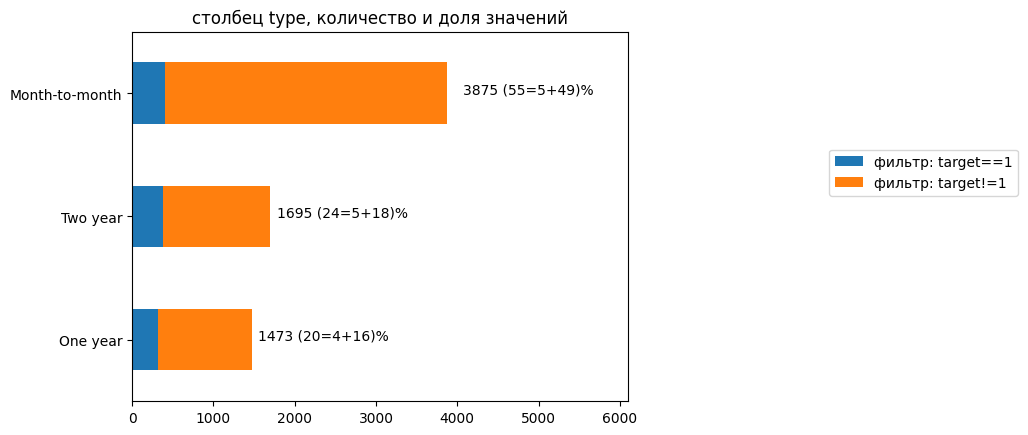

'⬇-------- столбец paperless_billing --------⬇'

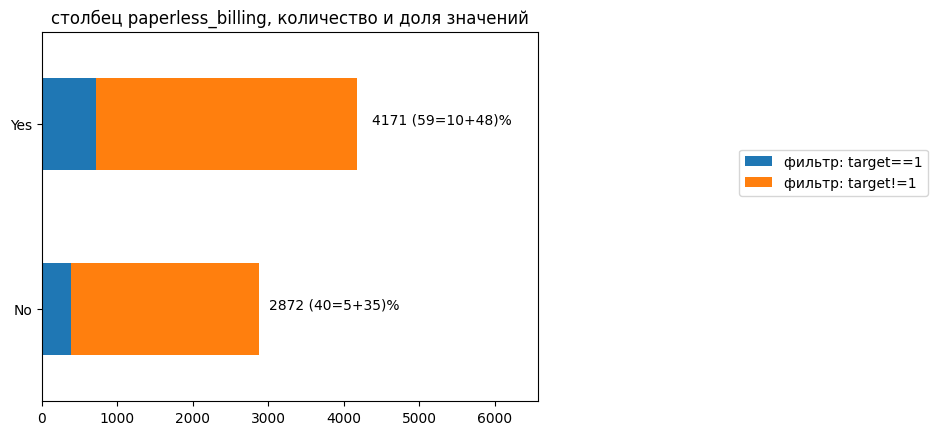

'⬇-------- столбец payment_method --------⬇'

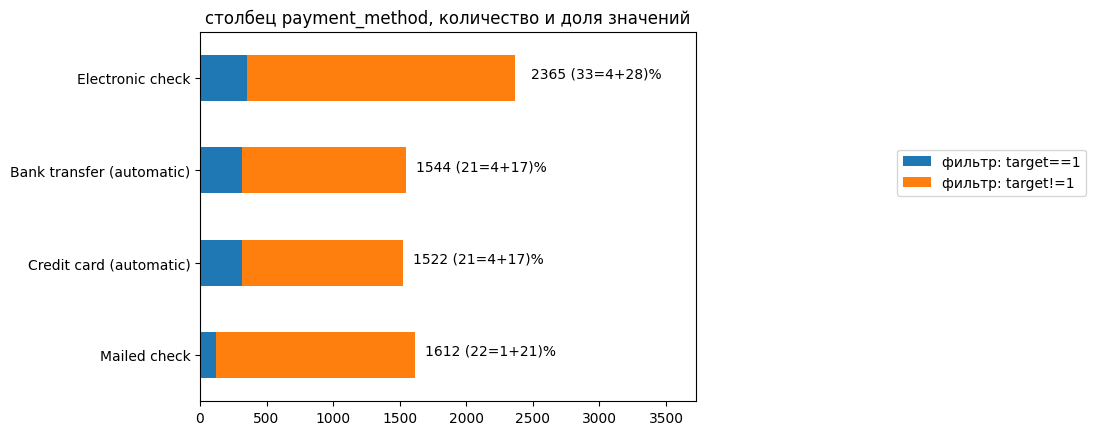

'⬇-------- Следующий признак: monthly_charges --------⬇'

'фильтр: target==1'

count    1101.000000
mean       75.546004
std        29.116213
min        18.400000
25%        56.150000
50%        84.200000
75%        99.500000
max       118.750000
Name: monthly_charges, dtype: float64

'фильтр: target!=1'

count    5942.000000
mean       62.763455
std        29.844462
min        18.250000
25%        30.062500
50%        69.200000
75%        87.237500
max       118.600000
Name: monthly_charges, dtype: float64

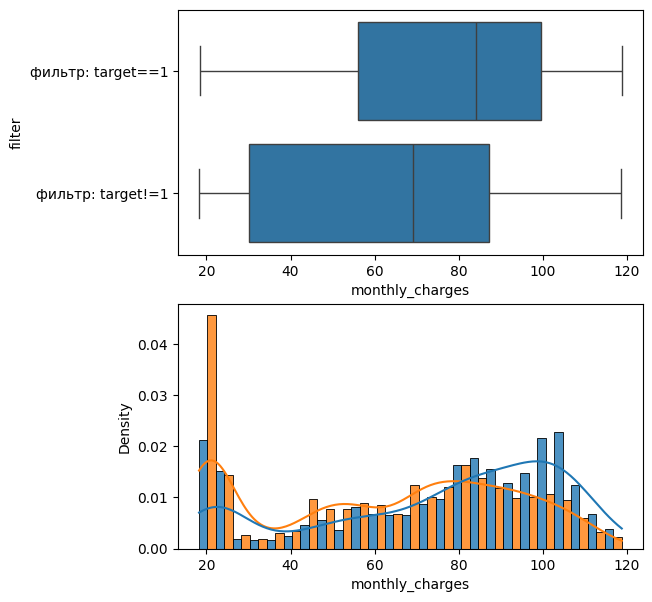

'⬇-------- Следующий признак: total_charges --------⬇'

'фильтр: target==1'

count    1101.000000
mean     2371.377275
std      1581.862275
min        77.840000
25%      1048.050000
50%      2139.030000
75%      3404.910000
max      7649.760000
Name: total_charges, dtype: float64

'фильтр: target!=1'

count    5942.000000
mean     2067.866420
std      2193.898483
min         0.000000
25%       374.352500
50%      1192.800000
75%      3173.837500
max      9221.380000
Name: total_charges, dtype: float64

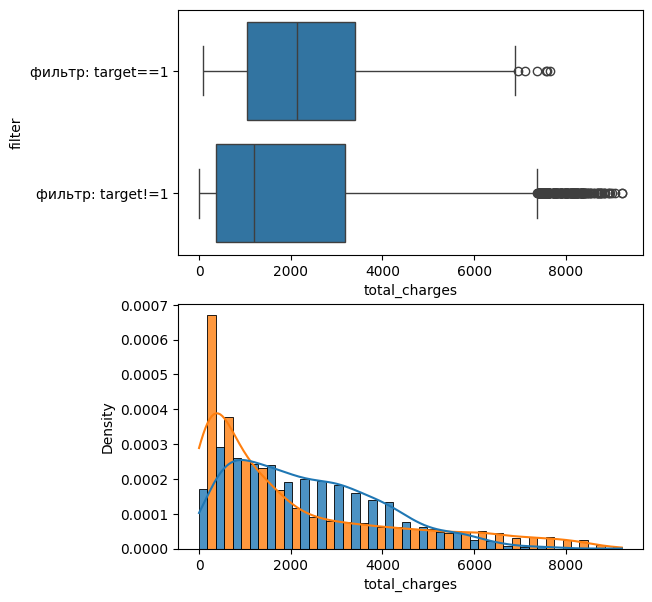

In [51]:
do_eda(contract_df, ignore_columns=['customer_id', 'target', 'begin_date_day', 'end_date_day', 'begin_date', 'end_date'], 
       filters=['target==1', 'target!=1'], sort_filter_index=0)

In [52]:
contract_df['begin_date_day'].describe()

count    7043.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: begin_date_day, dtype: float64

In [53]:
contract_df['begin_date_day'].value_counts()

begin_date_day
1    7043
Name: count, dtype: int64

Поле begin_date_day всегда = 1, удалим его, как бесполезный признак. Поле begin_date нам тоже больше не нужно:

In [54]:
contract_df = contract_df.drop (columns=['begin_date_day'])

'⬇-------- столбец gender --------⬇'

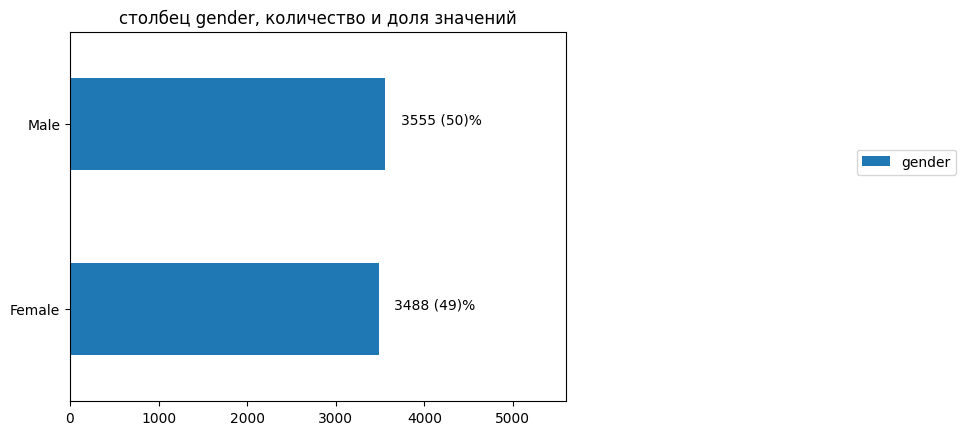

'⬇-------- столбец partner --------⬇'

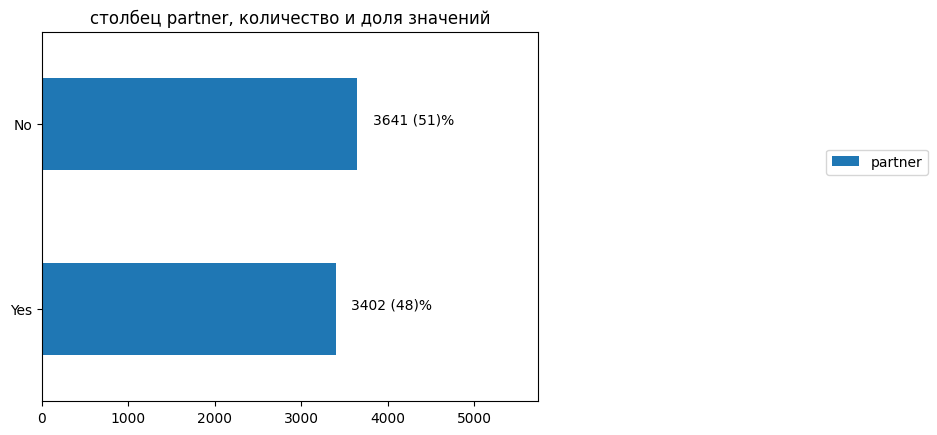

'⬇-------- столбец dependents --------⬇'

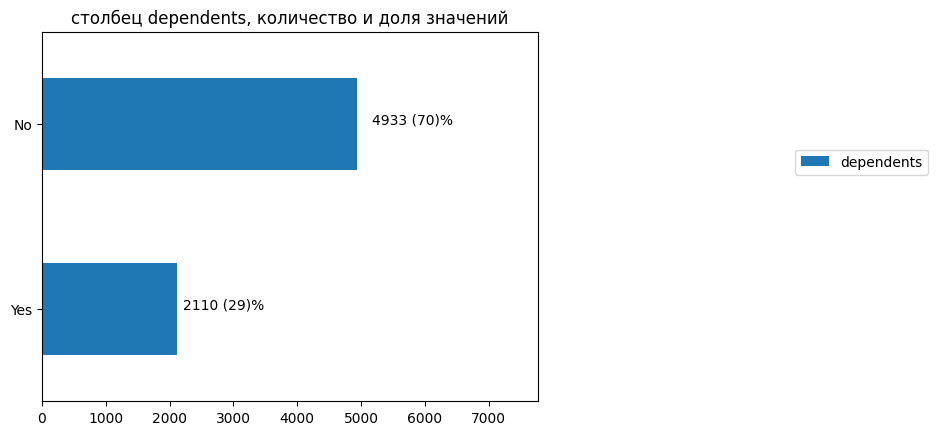

'⬇-------- Следующий признак: senior_citizen --------⬇'

,senior_citizen
count,7043.000000
mean,0.162147
std,0.368612
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


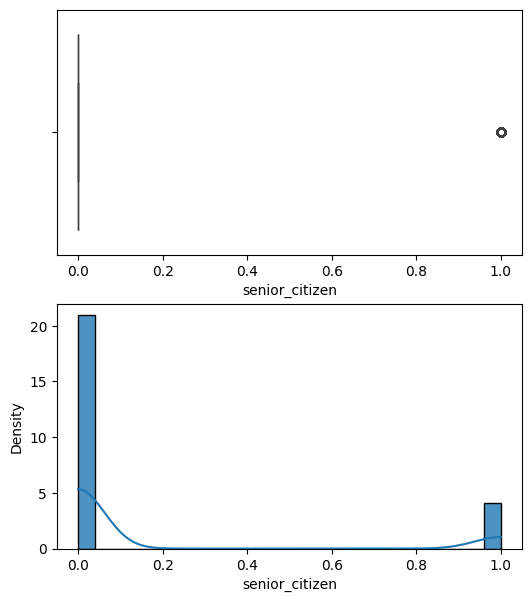

In [55]:
do_eda(personal_df, ignore_columns=['customer_id'])

'⬇-------- столбец internet_service --------⬇'

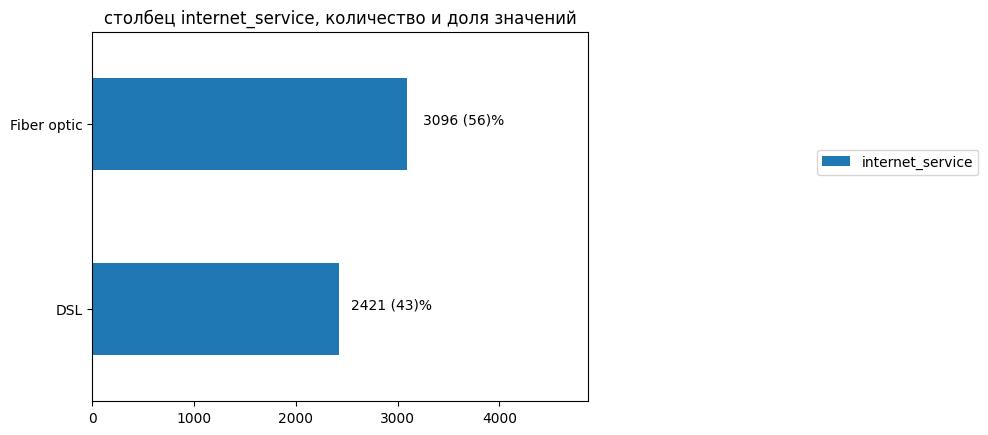

'⬇-------- столбец online_security --------⬇'

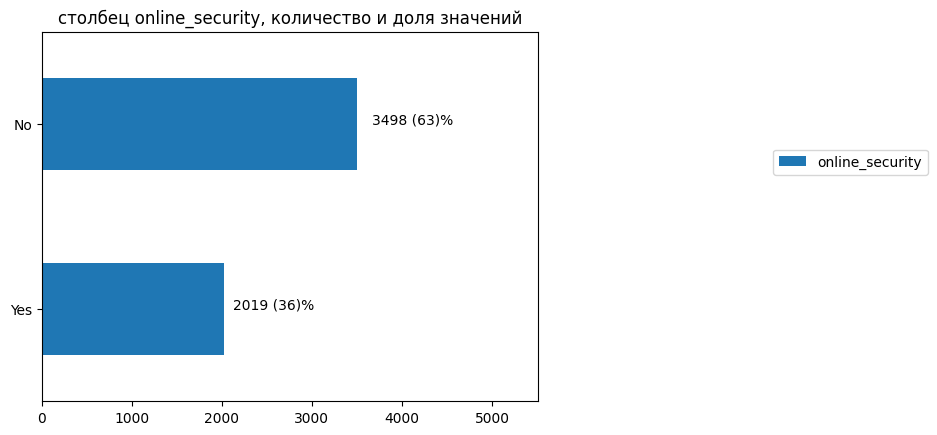

'⬇-------- столбец online_backup --------⬇'

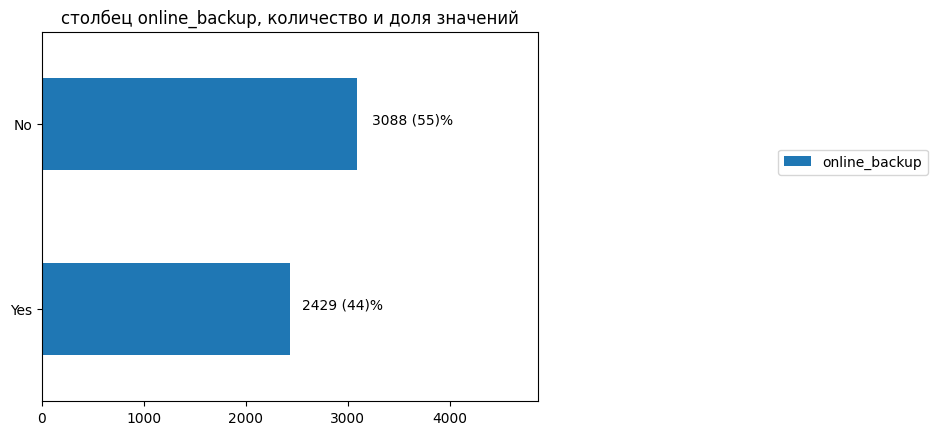

'⬇-------- столбец device_protection --------⬇'

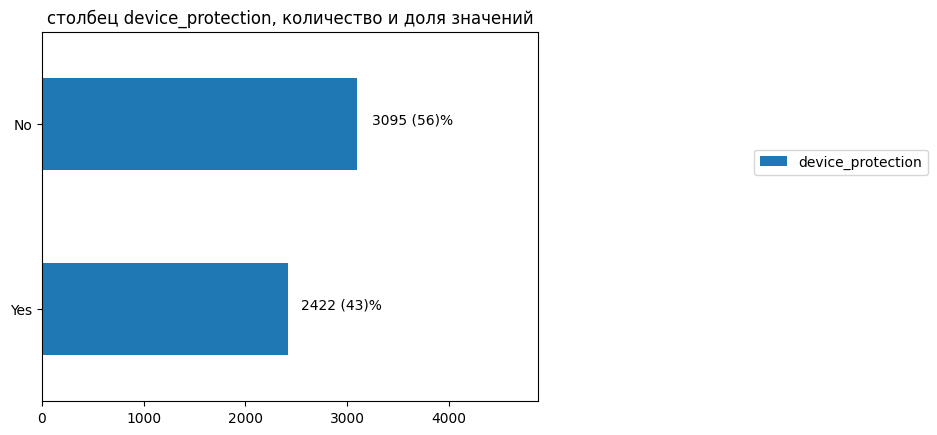

'⬇-------- столбец tech_support --------⬇'

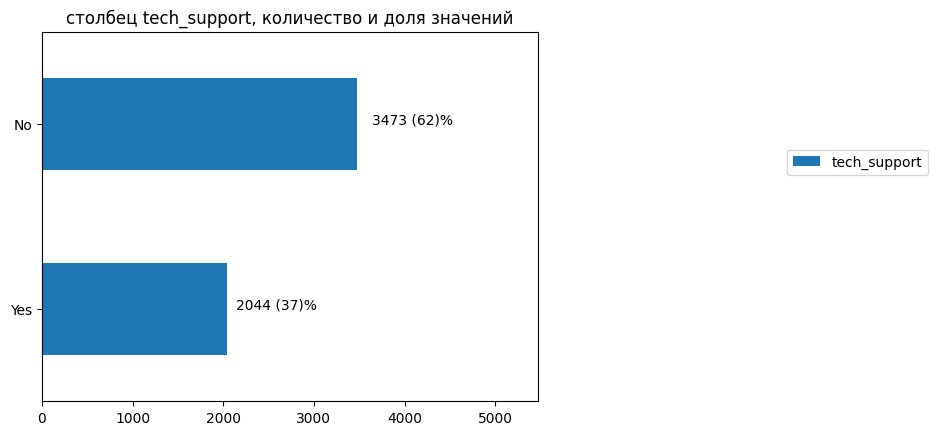

'⬇-------- столбец streaming_tv --------⬇'

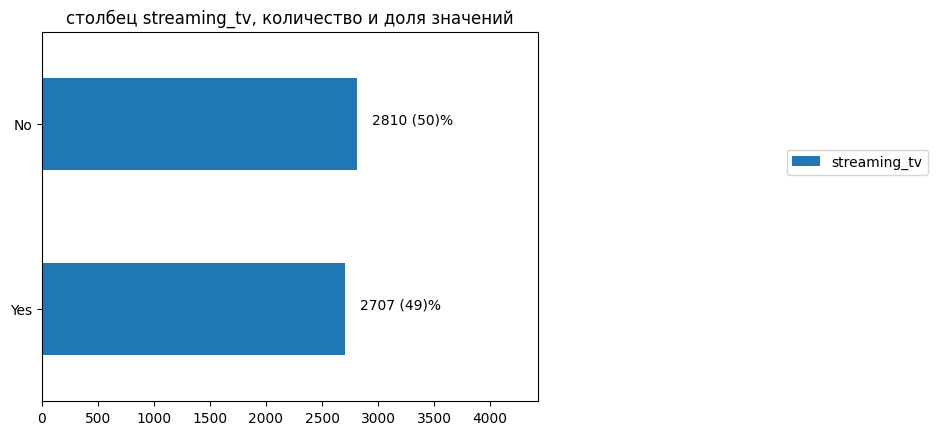

'⬇-------- столбец streaming_movies --------⬇'

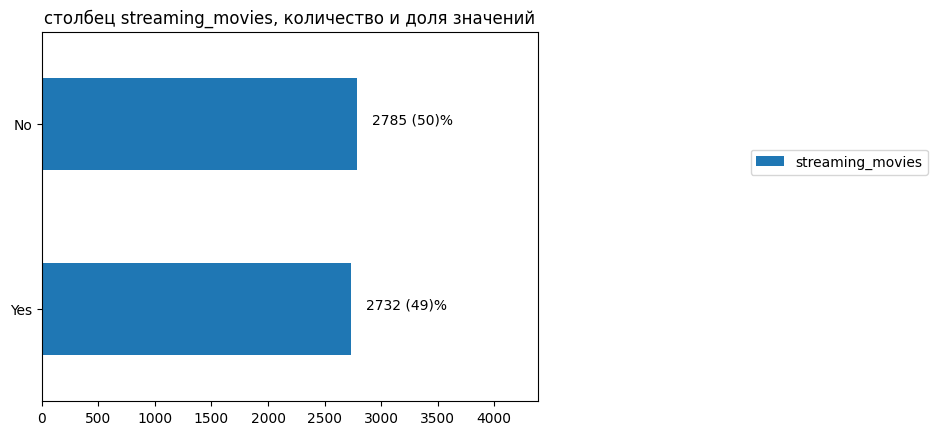

In [56]:
do_eda(internet_df, ignore_columns=['customer_id'])

'⬇-------- столбец multiple_lines --------⬇'

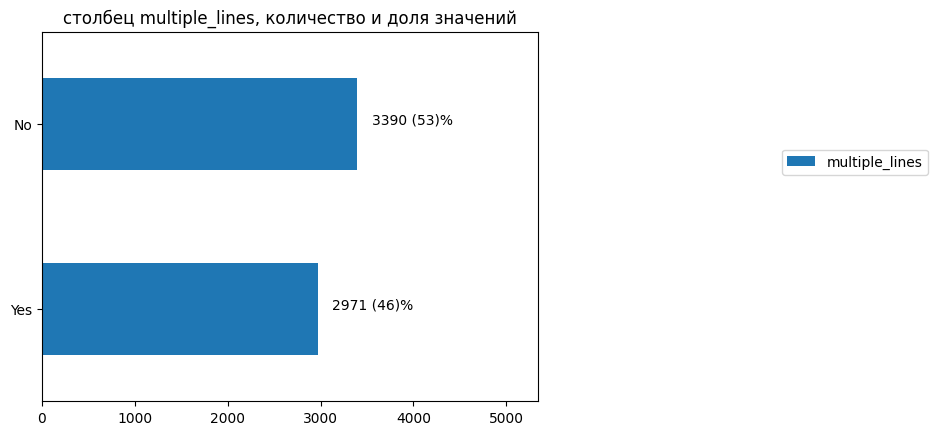

In [57]:
do_eda(phone_df, ignore_columns=['customer_id'])

Посмотрим отдельно на аномально высокие total_charges (больше 7000):

'⬇-------- столбец type --------⬇'

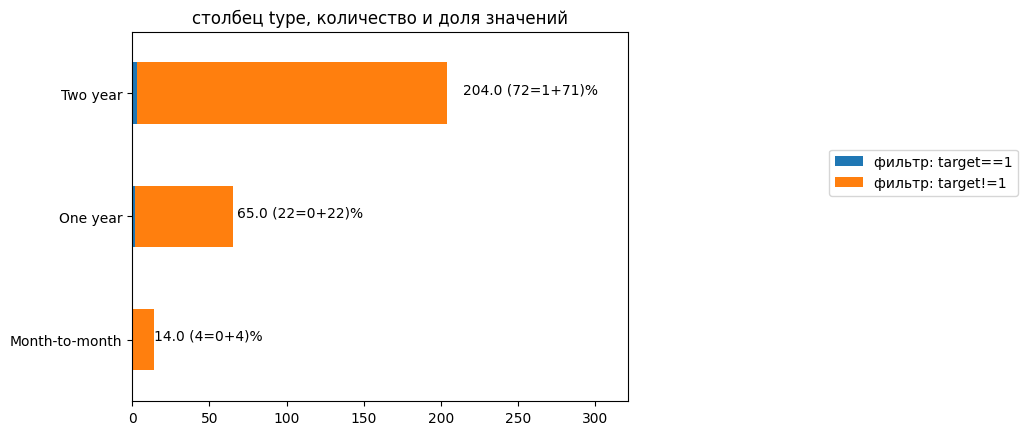

'⬇-------- столбец paperless_billing --------⬇'

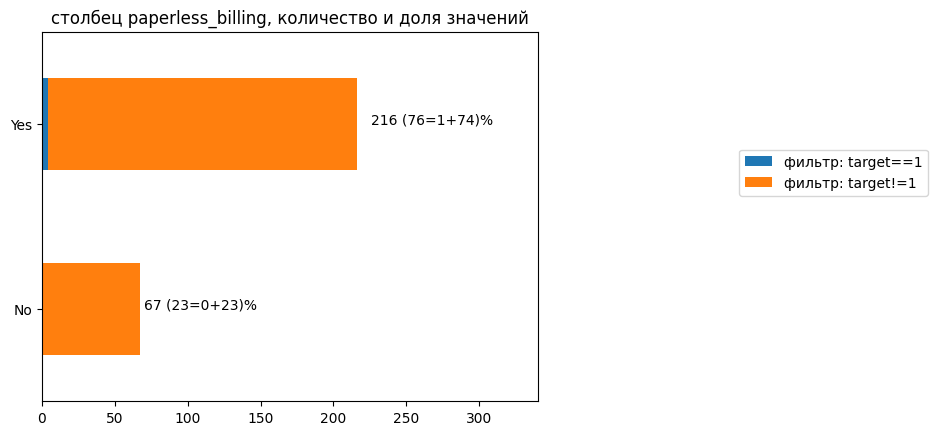

'⬇-------- столбец payment_method --------⬇'

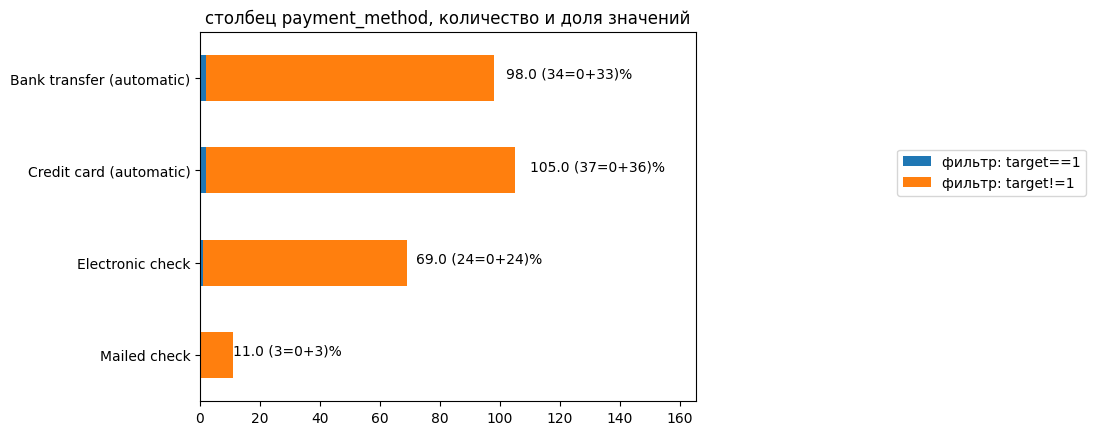

'⬇-------- Следующий признак: monthly_charges --------⬇'

'фильтр: target==1'

count      5.000000
mean     110.970000
std        2.652499
min      108.750000
25%      109.500000
50%      110.250000
75%      110.850000
max      115.500000
Name: monthly_charges, dtype: float64

'фильтр: target!=1'

count    278.000000
mean     108.099281
std        6.198594
min       89.400000
25%      104.912500
50%      109.100000
75%      112.975000
max      118.600000
Name: monthly_charges, dtype: float64

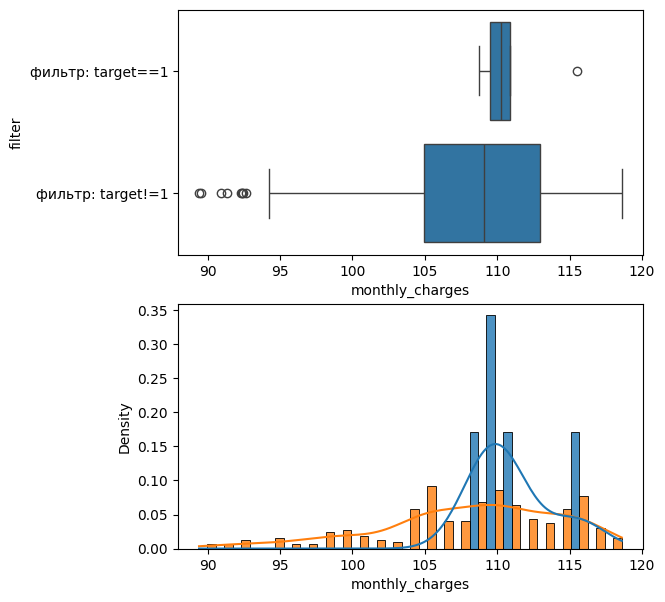

'⬇-------- Следующий признак: total_charges --------⬇'

'фильтр: target==1'

count       5.000000
mean     7457.398000
std       221.463246
min      7112.250000
25%      7362.500000
50%      7567.560000
75%      7594.920000
max      7649.760000
Name: total_charges, dtype: float64

'фильтр: target!=1'

count     278.000000
mean     7784.267482
std       520.842214
min      7002.000000
25%      7334.140000
50%      7735.700000
75%      8163.225000
max      9221.380000
Name: total_charges, dtype: float64

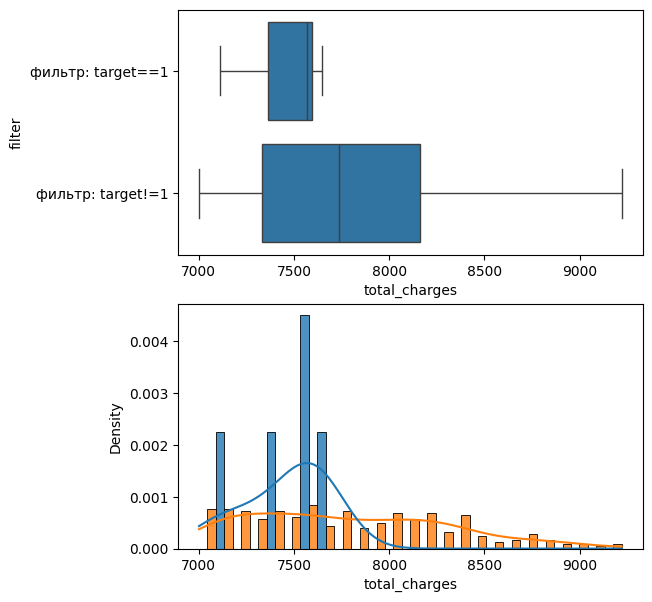

In [58]:
do_eda(contract_df [contract_df['total_charges'] > 7000], 
       ignore_columns=['customer_id', 'target', 'begin_date_day', 'begin_date', 'end_date'], 
       filters=['target==1', 'target!=1'], sort_filter_index=0)

### Объединим таблицы по полю customer_id

In [59]:
merged_df = contract_df.merge(personal_df, on='customer_id', how='left') \
                        .merge(internet_df, on='customer_id', how='left') \
                        .merge(phone_df, on='customer_id', how='left')

In [60]:
contract_df.shape

(7043, 13)

In [61]:
merged_df.shape

(7043, 25)

Количество записей не изменилось. 

Проверим, что теперь стало с пропусками:

In [62]:
show_nans(merged_df)

'empty parts:'

internet_service     21.67%
online_security      21.67%
online_backup        21.67%
device_protection    21.67%
tech_support         21.67%
streaming_tv         21.67%
streaming_movies     21.67%
multiple_lines        9.68%
dtype: object

Все пропуски - это услуги. Заполним их подходящими заглушками:

In [63]:
merged_df = merged_df.fillna("service wasn't connected")

Повторим EDA для объединённой таблице, как было запрошено в задании (и дополним выводы только новыми выявленными закономерностями):

'⬇-------- столбец type --------⬇'

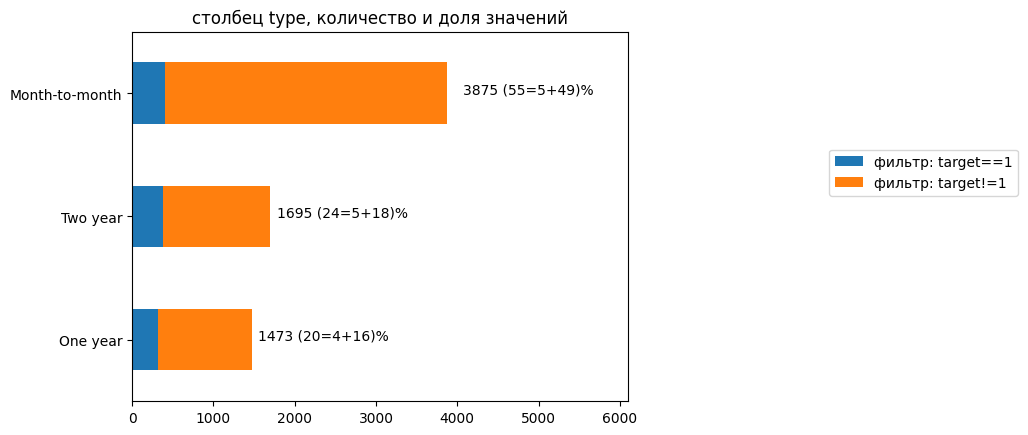

'⬇-------- столбец paperless_billing --------⬇'

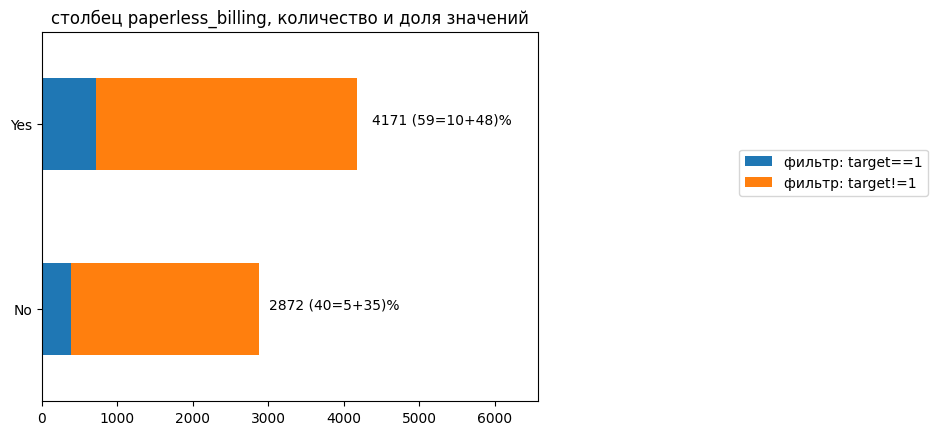

'⬇-------- столбец payment_method --------⬇'

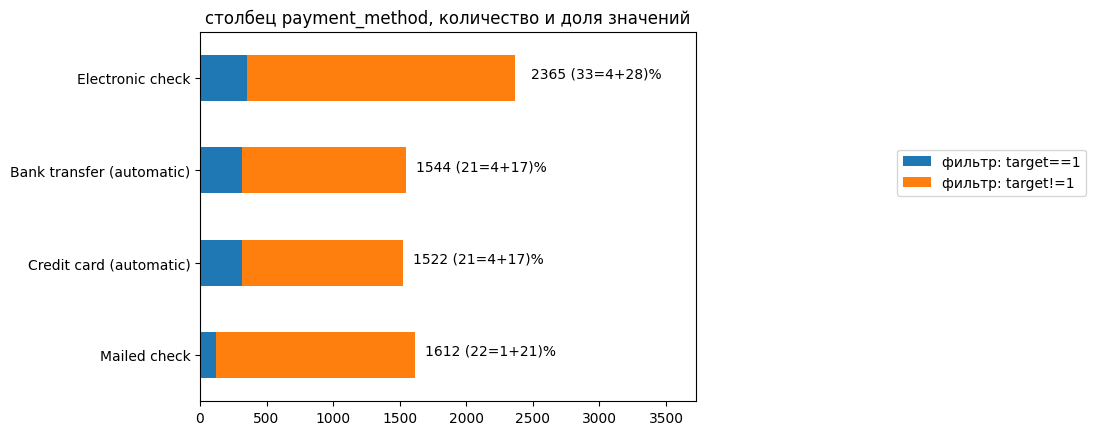

'⬇-------- столбец gender --------⬇'

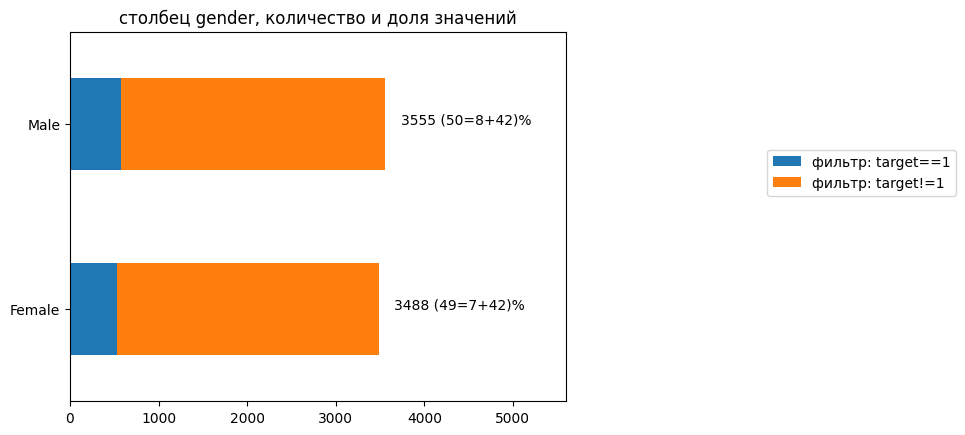

'⬇-------- столбец partner --------⬇'

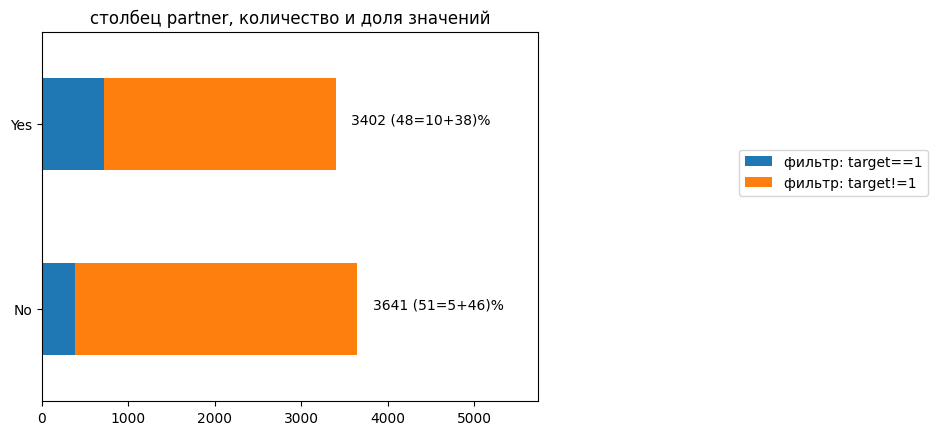

'⬇-------- столбец dependents --------⬇'

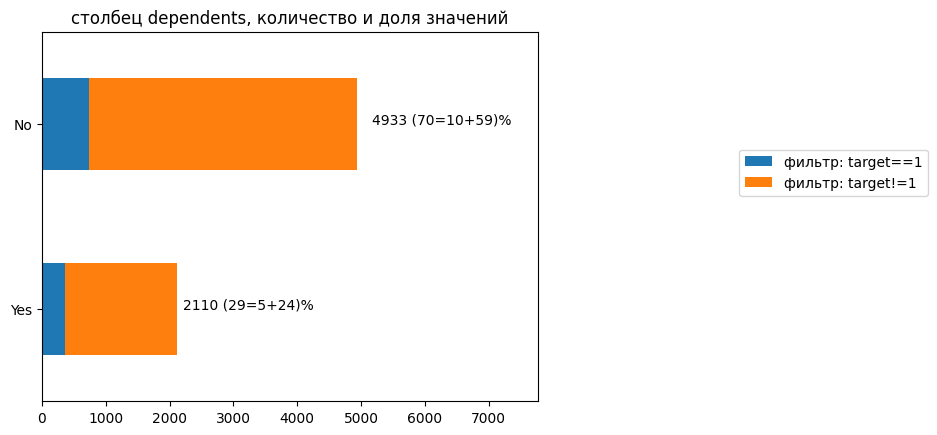

'⬇-------- столбец internet_service --------⬇'

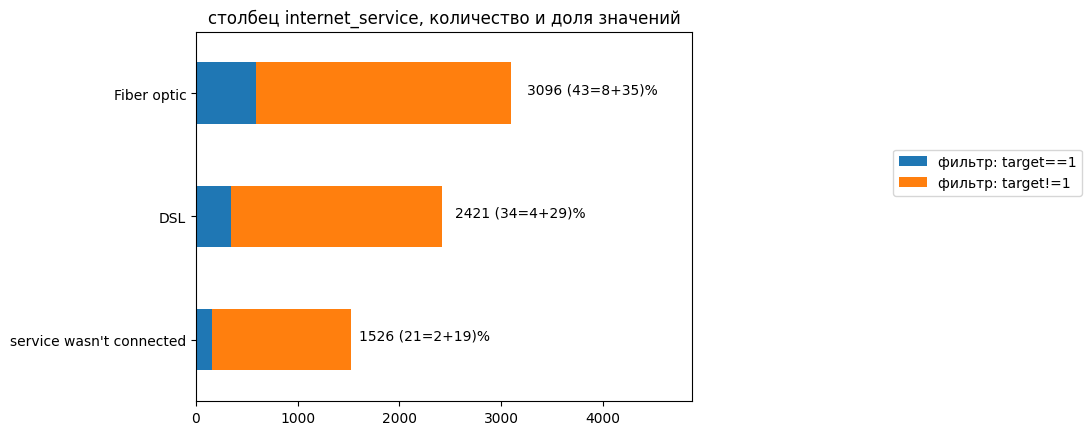

'⬇-------- столбец online_security --------⬇'

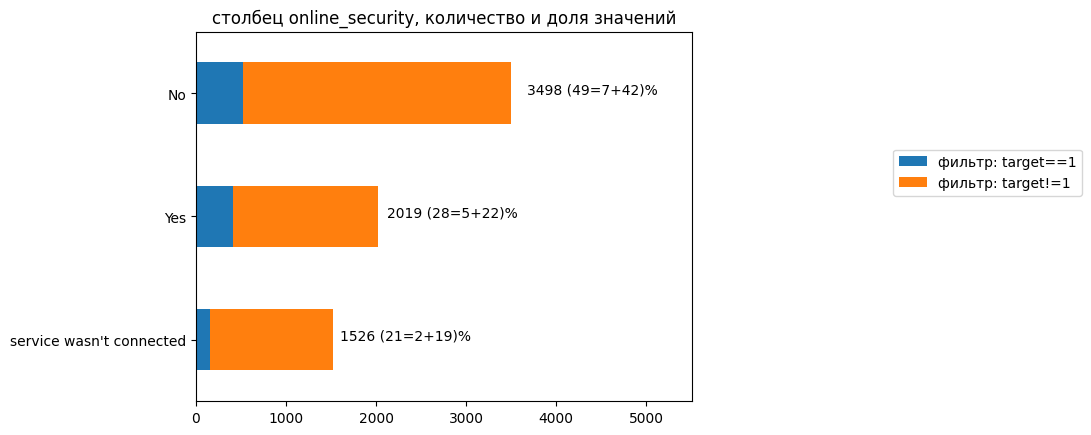

'⬇-------- столбец online_backup --------⬇'

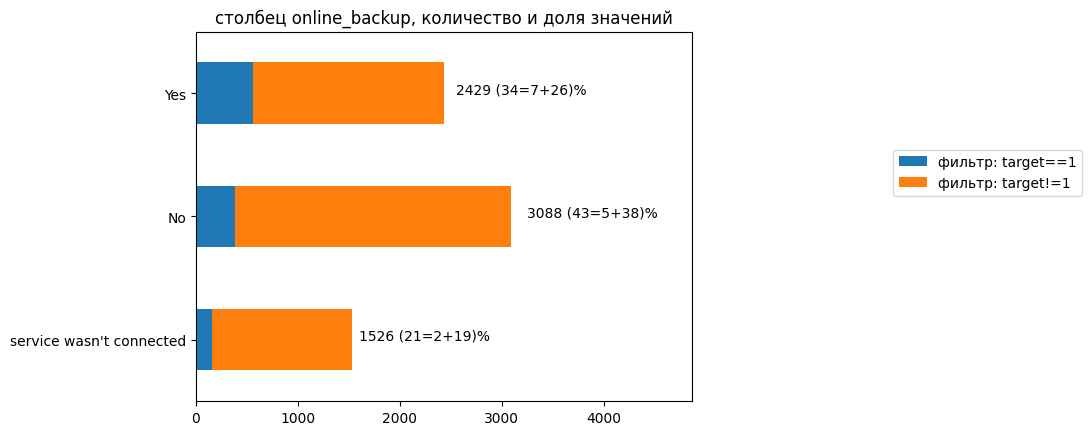

'⬇-------- столбец device_protection --------⬇'

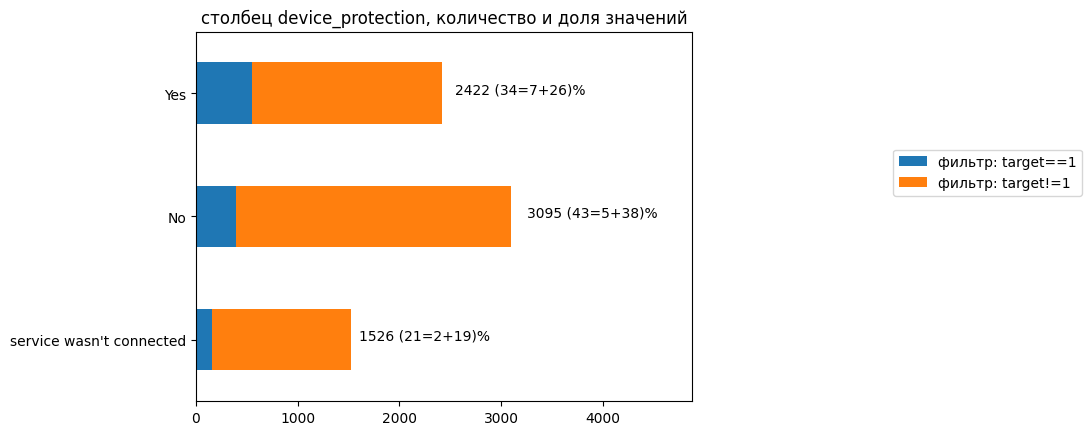

'⬇-------- столбец tech_support --------⬇'

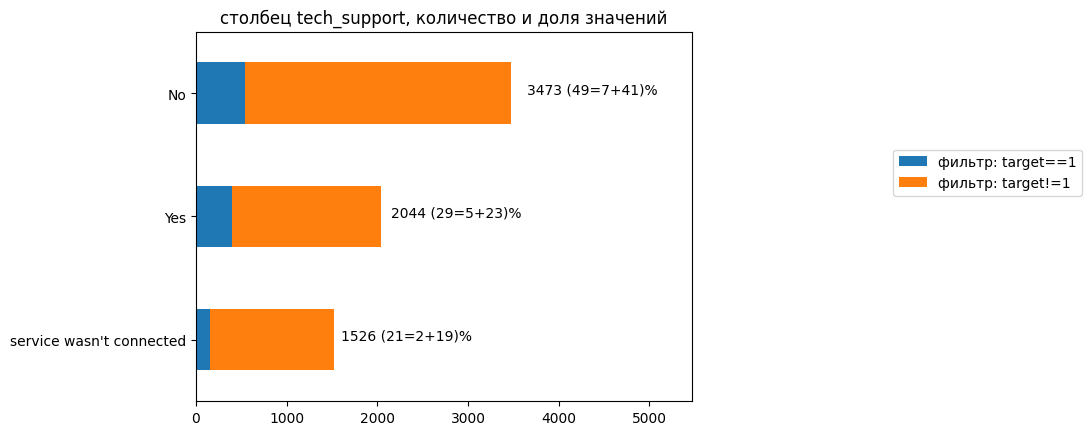

'⬇-------- столбец streaming_tv --------⬇'

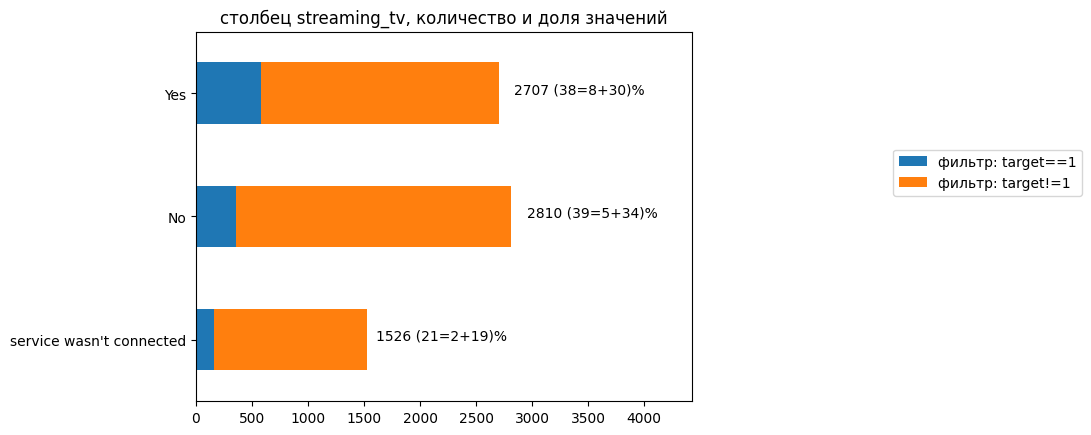

'⬇-------- столбец streaming_movies --------⬇'

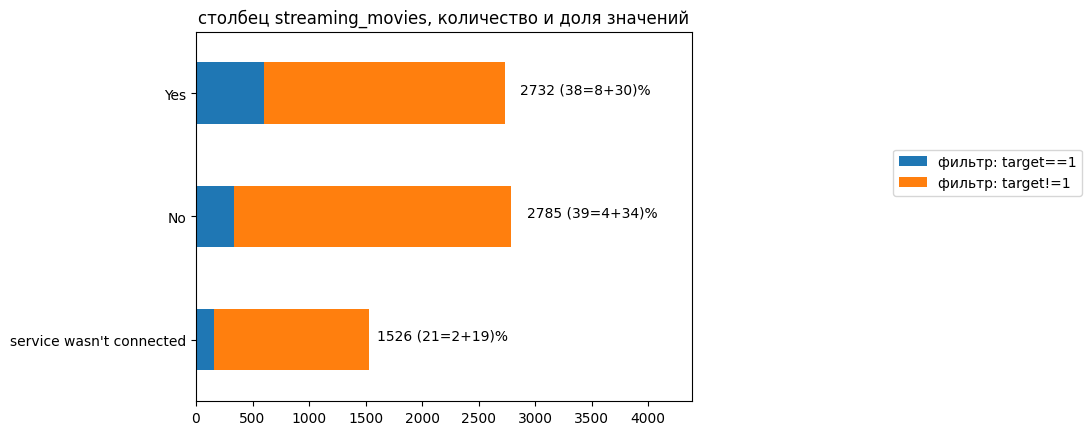

'⬇-------- столбец multiple_lines --------⬇'

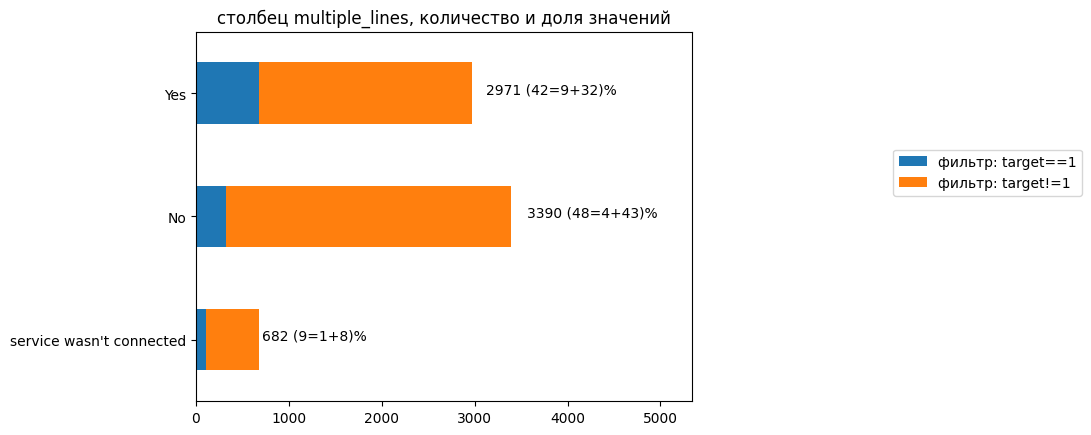

'⬇-------- Следующий признак: monthly_charges --------⬇'

'фильтр: target==1'

count    1101.000000
mean       75.546004
std        29.116213
min        18.400000
25%        56.150000
50%        84.200000
75%        99.500000
max       118.750000
Name: monthly_charges, dtype: float64

'фильтр: target!=1'

count    5942.000000
mean       62.763455
std        29.844462
min        18.250000
25%        30.062500
50%        69.200000
75%        87.237500
max       118.600000
Name: monthly_charges, dtype: float64

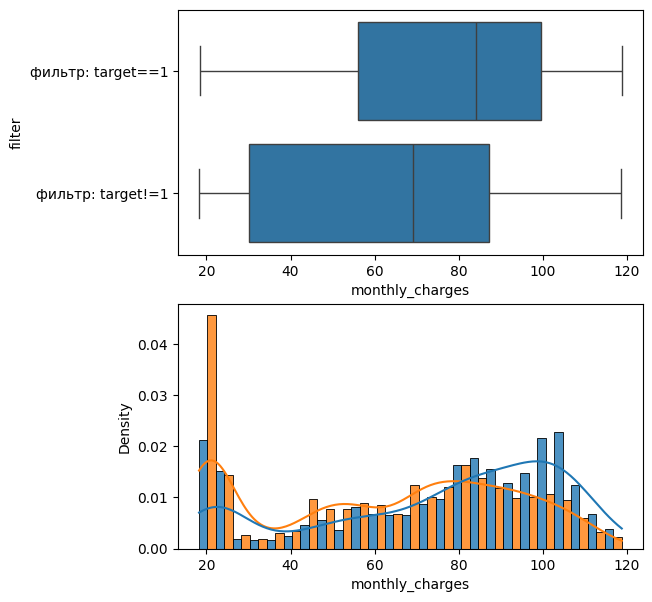

'⬇-------- Следующий признак: total_charges --------⬇'

'фильтр: target==1'

count    1101.000000
mean     2371.377275
std      1581.862275
min        77.840000
25%      1048.050000
50%      2139.030000
75%      3404.910000
max      7649.760000
Name: total_charges, dtype: float64

'фильтр: target!=1'

count    5942.000000
mean     2067.866420
std      2193.898483
min         0.000000
25%       374.352500
50%      1192.800000
75%      3173.837500
max      9221.380000
Name: total_charges, dtype: float64

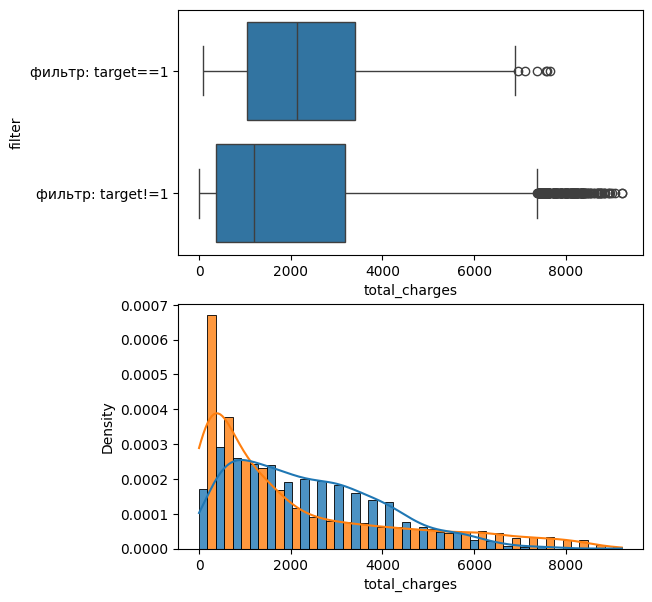

'⬇-------- Следующий признак: senior_citizen --------⬇'

'фильтр: target==1'

count    1101.000000
mean        0.210718
std         0.408003
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: senior_citizen, dtype: float64

'фильтр: target!=1'

count    5942.000000
mean        0.153147
std         0.360160
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: senior_citizen, dtype: float64

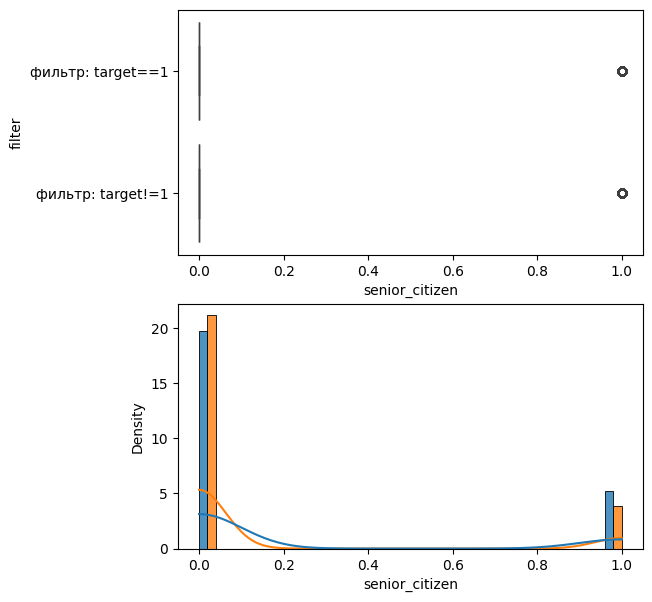

In [64]:
do_eda(merged_df, ignore_columns=['customer_id', 'target', 'begin_date_day', 'begin_date', 'end_date'], 
       filters=['target==1', 'target!=1'], sort_filter_index=0)

In [65]:
portrait = merged_df[['target', 'gender', 'senior_citizen', 'partner', \
                      'dependents', 'monthly_charges']].copy()

portrait ['доля мужчин'] = portrait['gender'].apply (lambda x: 1 if x == 'Male' else 0)
portrait = portrait.drop (columns=['gender'])

portrait ['partner'] = portrait['partner'].apply (lambda x: 1 if x == 'Yes' else 0)
portrait ['dependents'] = portrait['dependents'].apply (lambda x: 1 if x == 'Yes' else 0)

portrait = portrait.rename(columns={'dependents':'доля абонентов с детьми', 
                                    'monthly_charges':'средний ежемесячный платёж',
                                    'partner':'доля семейных',
                                    'senior_citizen':'доля пенсионеров'})
portrait['target'] = portrait['target'].apply(lambda x: "ушёл" if x == 1 else "остался")

display("Портрет ушедшего и оставшегося абонента:")
stats = pd.pivot_table(portrait, columns=['target'])
stats = stats.round(1)
stats ['разница (остался-ушёл)'] = stats ['остался'] - stats ['ушёл']
display(stats)

'Портрет ушедшего и оставшегося абонента:'

target,остался,ушёл,разница (остался-ушёл)
доля абонентов с детьми,0.3,0.3,0.0
доля мужчин,0.5,0.5,0.0
доля пенсионеров,0.2,0.2,0.0
доля семейных,0.5,0.7,-0.2
средний ежемесячный платёж,62.8,75.5,-12.7


## Выводы и задачи по итогам EDA
Таблица contract_df

1. данные в датасете представлены за период: 2013-10-01 - 2020-02-01
1. большинство (55%) контрактов с помесячной оплатой, при этом у ушедших тип контракта распределён примерно одинаково (5%, 5%, 4%) - то есть, уходят не зависимо от этого признака
1. большинство счетов (59%) электронные
1. наиболее популярный метод оплаты (33%) - электронный чек
1. данные представлены за период с октября 2013 - по январь 2020 г.
1. по графику распределения begin_date видно, что общее количество новых абонентов планомерно растёт - был пик в самом начале в 2014 году (возможно, активно привлекали клиентов в рамках стартового маркетинга). 
    1. 💡 При этом количество абонентов заключённых контрактов, завершившихся в дальнейшем расторжением - снижается год от года и приближается к (от сотни в квартал) к нулю. Это хороший знак.
1. 💡 судя по графику распределения end_date, количество расторгнутых контрактов растёт от года к году. Это плохой знак. Кажется, что это противоречит предыдущему выводу. Тут помогла бы помощь ревьюера 👷🚨[SOS].
1. Наиболее частый месяц расторжения контракта - ноябрь (с незначительным преобладанием).
1. На графике monthly_charges выделяется пик платежей (более 1000) - стоимостью около 20 денежных единиц в месяц, и это пользователи, которые не ушли. Наиболее активная часть платежей лежит в диапазоне 45-110.
    1. 💡 Медианный ежемесячный платёж ушедших пользователей 84, в то время как оставшихся - 69. Это говорит о том, что ушедшие были готовы платить больше (возможно, они более требовательны к качеству связи или чему-то ещё). 
    1. Это же наблюдение касается и медианы общей суммы расходов (график total_charges).
1. На графике total_charges виден тренд, что больше всего контрактов с наименьшими общими расходами, и меньше всего - с наибольшими.
    1. 👷✅ boxplot показывает аномалии при total_charges, но большие траты на связь - возможны. Посмотрим на них отдельно:
        1. 72% оплачивают сразу на 2 года, 99% остаются текущими клиентами
        1. Почти все такие клиенты присоединились в 2014 году, т. е. почти в самом начале наблюдений.
        1. Итого - удалять такие "аномалии" не будем, т. к. они выглядят как нормальные клиенты.
1. Чаще всего контракт заключают в феврале. Реже всего в апреле и мае.
1. Чаще всего закрывают контракт, заключённый в феврале.


Таблица personal_df

1. Мужчин и женщин примерно поровну.
1. У 51% абонентов есть супруг, у 49% - нет.
1. 💡 У 70% абонентов есть дети. Могут быть значительно востребованы продукты для детей.
1. Пенсионеров лишь 16%

Таблица internet_df

1. 56% Fiber optic, 43% DSL
1. лишь 36% абонентов пользуется услугой online security
1. 44% абонентов пользуется услугой onlne backup
1. 43% абонентов пользуется услугой device protection
1. ⚠️37% абонентов обращалась в tech_support. Чем меньше этот показатель, тем лучше.
1. 49% абонентов пользуется услугой streaming tv
1. 49% абонентов пользуется услугой streaming movies


Таблица phone
1. 46% абонентов пользуется подключением телефона к нескольким линиям одновременно


# Конструирование новых признаков

In [66]:
merged_df.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,begin_date_year,begin_date_month,...,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,2020-01-01,2020-02-01,Month-to-month,Yes,Electronic check,29.85,31.04,2020,1,...,Yes,No,DSL,No,Yes,No,No,No,No,service wasn't connected
1,5575-GNVDE,2017-04-01,2020-02-01,One year,No,Mailed check,56.95,2071.84,2017,4,...,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2020-02-01,Month-to-month,Yes,Mailed check,53.85,226.17,2019,10,...,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,2020-02-01,One year,No,Bank transfer (automatic),42.30,1960.60,2016,5,...,No,No,DSL,Yes,No,Yes,Yes,No,No,service wasn't connected
4,9237-HQITU,2019-09-01,2020-02-01,Month-to-month,Yes,Electronic check,70.70,353.50,2019,9,...,No,No,Fiber optic,No,No,No,No,No,No,No


- нам придётся удалить признак end_date, т. к. его использование будет приводить к утечке
- при этом признак begin date (год или месяц) - заменим лучше на признак длительности контракта абонента:

In [67]:
merged_df ['duration_days'] = (merged_df['end_date'] - merged_df['begin_date']).dt.days

- Также нам не нужен столбец с id клиента, т. к. он не должен быть признаком

In [68]:
merged_df = merged_df.drop (columns=['customer_id', 'begin_date', 'end_date',
                                     'begin_date_year', 'begin_date_month',  
                                     'end_date_year', 'end_date_month'])

# Проверим мультиколлинеарность

In [69]:
merged_df.head()

,type,paperless_billing,payment_method,monthly_charges,total_charges,target,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,duration_days
0,Month-to-month,Yes,Electronic check,29.85,31.04,0,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,service wasn't connected,31
1,One year,No,Mailed check,56.95,2071.84,0,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No,1036
2,Month-to-month,Yes,Mailed check,53.85,226.17,0,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No,123
3,One year,No,Bank transfer (automatic),42.30,1960.60,0,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,service wasn't connected,1371
4,Month-to-month,Yes,Electronic check,70.70,353.50,0,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No,153


'Мультиколлинеарные фичи для удаления:'

['internet_service',
 'streaming_movies',
 'device_protection',
 'tech_support',
 'online_backup',
 'online_security']

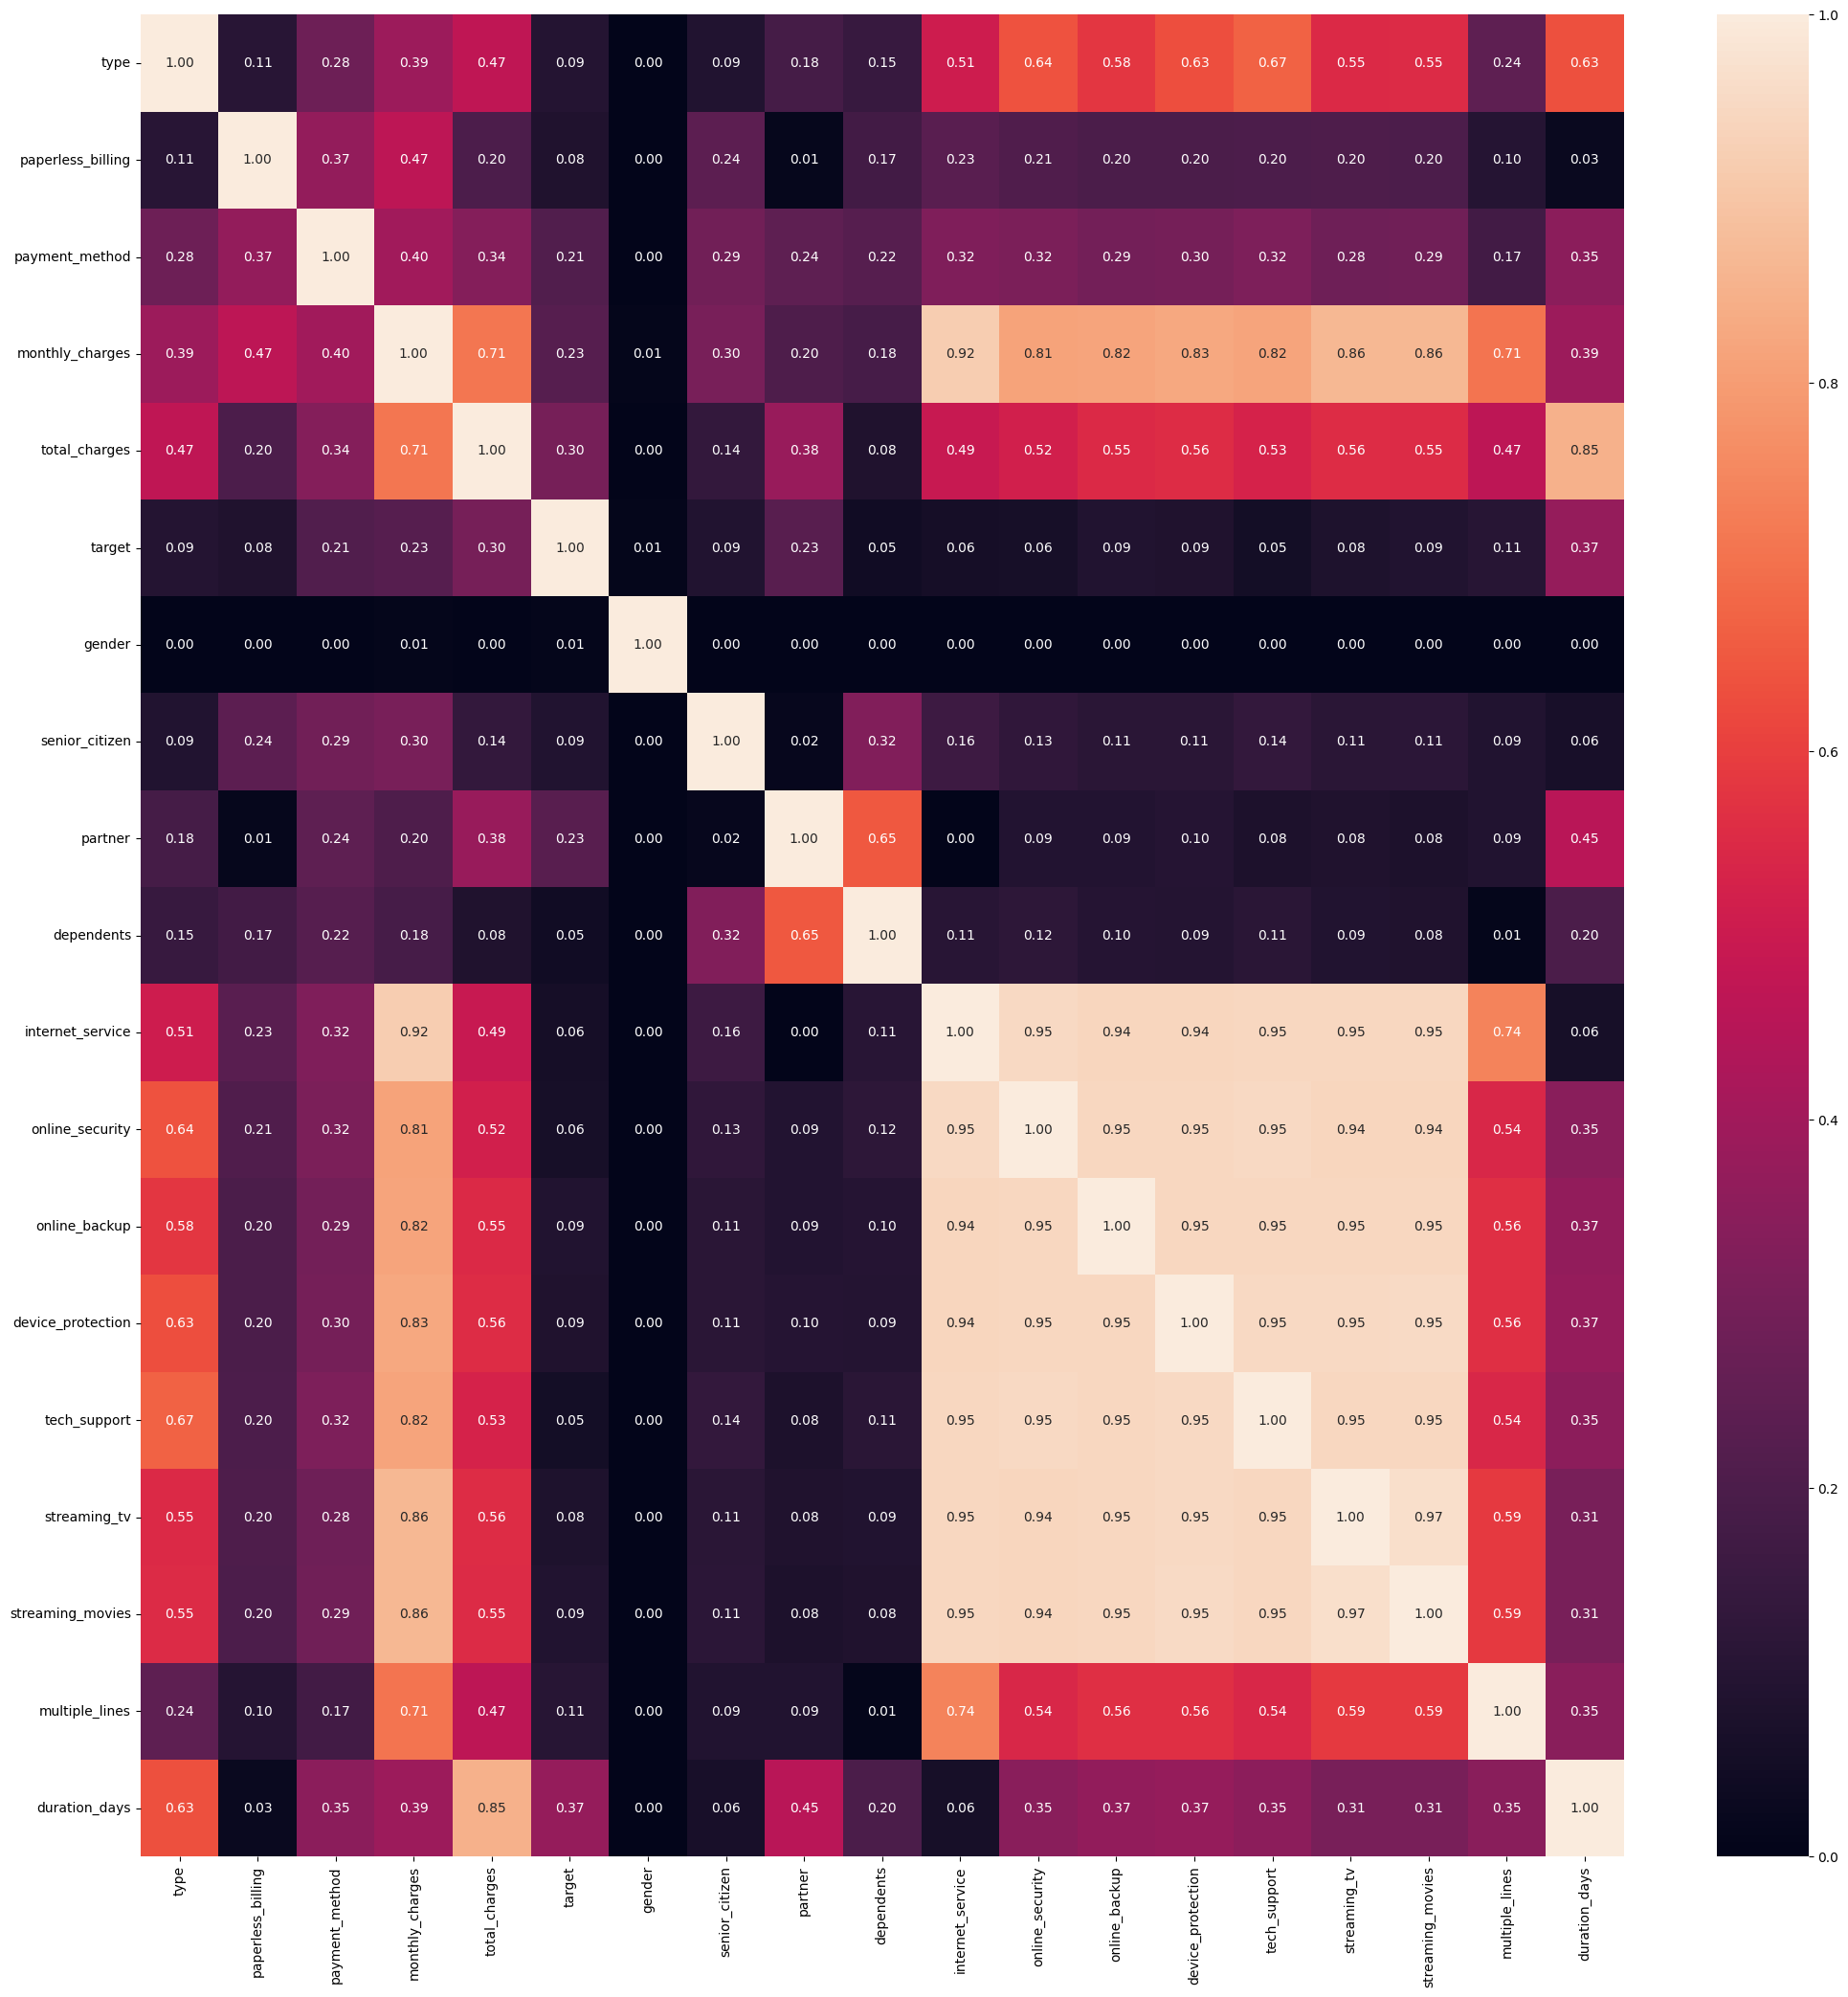

In [70]:
interval_cols=['monthly_charges', 'total_charges', 'duration_days']
   
bins = {}
for c in interval_cols:
    bins[c] = 10;

_, ax = plt.subplots(figsize=(25,25))
ph_mx = merged_df.phik_matrix(interval_cols=interval_cols, bins=bins)
sns.heatmap(ph_mx, annot=True, fmt='.2f', ax=ax);

columns_to_delete, ph_mx_no_mc = get_multicollinear_features (ph_mx)
display ("Мультиколлинеарные фичи для удаления:")
display (columns_to_delete)


*Как правило, о мультиколлинеарности говорят при значении коэффициента корреляции от 0.9 до 0.95 по модулю. В такой ситуации лишние коррелирующие признаки нужно удалять из обучающей выборки.*

Удалим избыточные столбцы:

In [71]:
merged_df = merged_df.drop(columns_to_delete, axis=1)

In [72]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   type               7043 non-null   object 
 1   paperless_billing  7043 non-null   object 
 2   payment_method     7043 non-null   object 
 3   monthly_charges    7043 non-null   float64
 4   total_charges      7043 non-null   float64
 5   target             7043 non-null   int64  
 6   gender             7043 non-null   object 
 7   senior_citizen     7043 non-null   int64  
 8   partner            7043 non-null   object 
 9   dependents         7043 non-null   object 
 10  streaming_tv       7043 non-null   object 
 11  multiple_lines     7043 non-null   object 
 12  duration_days      7043 non-null   int64  
dtypes: float64(2), int64(3), object(8)
memory usage: 715.4+ KB


In [73]:
merged_df.head()

,type,paperless_billing,payment_method,monthly_charges,total_charges,target,gender,senior_citizen,partner,dependents,streaming_tv,multiple_lines,duration_days
0,Month-to-month,Yes,Electronic check,29.85,31.04,0,Female,0,Yes,No,No,service wasn't connected,31
1,One year,No,Mailed check,56.95,2071.84,0,Male,0,No,No,No,No,1036
2,Month-to-month,Yes,Mailed check,53.85,226.17,0,Male,0,No,No,No,No,123
3,One year,No,Bank transfer (automatic),42.30,1960.60,0,Male,0,No,No,No,service wasn't connected,1371
4,Month-to-month,Yes,Electronic check,70.70,353.50,0,Female,0,No,No,No,No,153


# Разобъём выборку на тренировочную и тестовую (со стратификацией по целевому признаку в случае классификации)

In [74]:
X = merged_df.drop(['target'], axis=1)
y = merged_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=RANDOM_STATE
)

# Проверим сбалансированность тренировочной выборки относительно целевого класса (в случае классификации)

In [75]:
y_train.value_counts(normalize=True)

target
0    0.842295
1    0.157705
Name: proportion, dtype: float64

In [76]:
y_train.value_counts()

target
0    4449
1     833
Name: count, dtype: int64

Для нейросети оставим классы несбалансированы. Объясняли, что нейросети более устойчивы к несбалансированности классов.

# Обучение классических моделей

## Pipeline

In [77]:
cat_columns = ['type', 'paperless_billing', 'payment_method', 'gender', 
               'partner', 'dependents', 'streaming_tv', 'multiple_lines', 
               'senior_citizen']

In [78]:
for c in X_train.columns:
    if X_train[c].dtype == 'O':
        X_train[c] = X_train[c].astype("category")
display(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 5282 entries, 2655 to 5257
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   type               5282 non-null   category
 1   paperless_billing  5282 non-null   category
 2   payment_method     5282 non-null   category
 3   monthly_charges    5282 non-null   float64 
 4   total_charges      5282 non-null   float64 
 5   gender             5282 non-null   category
 6   senior_citizen     5282 non-null   int64   
 7   partner            5282 non-null   category
 8   dependents         5282 non-null   category
 9   streaming_tv       5282 non-null   category
 10  multiple_lines     5282 non-null   category
 11  duration_days      5282 non-null   int64   
dtypes: category(8), float64(2), int64(2)
memory usage: 248.7 KB


None

In [ ]:
cat_columns = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_columns = X_train.select_dtypes(include=["number"]).columns.tolist()

In [80]:
ohe_pipe = Pipeline(
     [   ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
         ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
     ])

ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

ohe_data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, cat_columns),
        ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)

ord_data_preprocessor = ColumnTransformer(
    [
        ('ord', ord_pipe, cat_columns),
        ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)

In [ ]:
pipe_final = Pipeline([
    ('preprocessor', ohe_data_preprocessor), # по умолчанию ohe
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [82]:
%%time
param_grid = [
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced')],
        'models__max_depth': [4,7],
        'models__max_features': [10, 50],
        "preprocessor": [ord_data_preprocessor]
    }
    ,
    {
        'models': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': [3, 7, 10],
        'models__min_samples_split': [5, 10],
        'models__min_samples_leaf': [2, 4],
        'models__bootstrap': [True, False],
    }
    ,
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1',
            class_weight='balanced'
        )],
        'models__C': range(1, 3),
    }
    ,
    {
        'models': [CatBoostClassifier(verbose=0, random_seed=RANDOM_STATE)],
        "models__learning_rate": [0.03, 0.1, 1],
        "models__iterations": [100, 300],
        "models__max_depth": [2, 10],
        "models__colsample_bylevel": [0.1, 0.3, 0.8],
        "models__l2_leaf_reg": [0,10],
        "models__bagging_temperature": [0,10],
        "preprocessor": [ord_data_preprocessor]
    }
    ,
    {
        'models': [MLPClassifier(max_iter=2000, random_state=RANDOM_STATE)],
        'models__hidden_layer_sizes': [(50,), (50, 50), (100, 50)],
        'models__activation': ['tanh', 'relu'],
        'models__solver': ['adam', 'sgd'],
        'models__alpha': np.logspace(-5, -1, 5),
        'models__learning_rate': ['constant', 'adaptive'],
    }

##v1    ,
##v1    {
##v1        'models': [SVC(
##v1            random_state=RANDOM_STATE, 
##v1            kernel='linear', probability=True, class_weight='balanced'
##v1        )],
##v1        'models__kernel': ['poly', 'rbf'],
##v1        'models__degree': [2, 5, 10],
##v1        'models__C': range(2, 3),
##v1    }
]

#search = RandomizedSearchCV(
search = GridSearchCV(
    pipe_final, 
    param_grid,
    cv=3,
    scoring='roc_auc',
#    n_iter=50,
    verbose = 10,
    n_jobs=-1
)

search.fit(X_train, y_train)

display (search.best_params_)

best_model = search.best_estimator_

Fitting 3 folds for each of 294 candidates, totalling 882 fits


{'models': <catboost.core.CatBoostClassifier at 0x2375bf68bd0>,
 'models__bagging_temperature': 0,
 'models__colsample_bylevel': 0.8,
 'models__iterations': 300,
 'models__l2_leaf_reg': 0,
 'models__learning_rate': 1,
 'models__max_depth': 2,
 'preprocessor': ColumnTransformer(remainder='passthrough',
                   transformers=[('ord',
                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('ord',
                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                  unknown_value=nan)),
                                                  ('simpleImputer_after_ord',
                                                   SimpleImputer(strategy='most_frequent'))]),
                                  ['type', 'paperless_billing', 

CPU times: total: 13.5 s
Wall time: 19min 23s


# Анализ результатов

## Метрики качества на кроссвалидации

In [83]:
display (f'Метрика качества лучшей модели на кроссвалидации: {search.best_score_:.4f}')

'Метрика качества лучшей модели на кроссвалидации: 0.9048'

## Метрики качества на тестовой выборке

Лучшая модель - catboost, сделаем замер тестовой выборки на ней:

In [84]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1493
           1       0.87      0.67      0.76       268

    accuracy                           0.94      1761
   macro avg       0.91      0.83      0.86      1761
weighted avg       0.93      0.94      0.93      1761



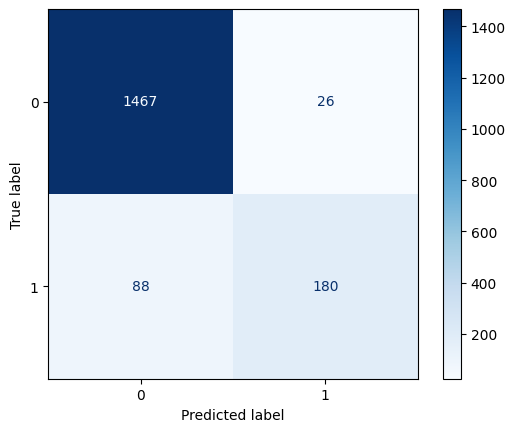

In [85]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues');

Описание для бизнеса:
- 180 True Positives - столько раз мы верно распознали уход абонента
- 1467 True Negatives - столько раз мы верно распознали оставшегося абонента
- 26 False Positives -  столько раз мы ложно распознали оставшегося абонента как ушедшего
- 88 False Negatives -  столько раз мы ложно распознали ушедшего абонента как оставшегося

Значит в случае внедрения модели мы бы получили возможность удержать 180 абонентов (88 бы не удержали). Смогли бы сократить отток в данном случае на 180/(180+88) = 67%.

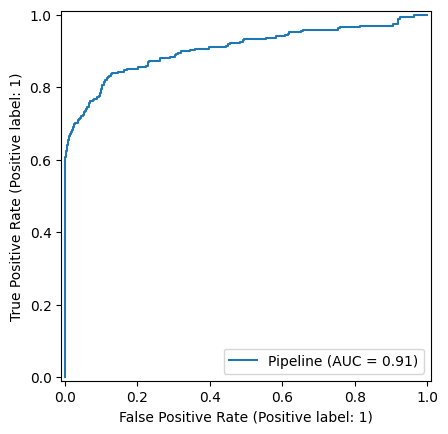

In [86]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test);

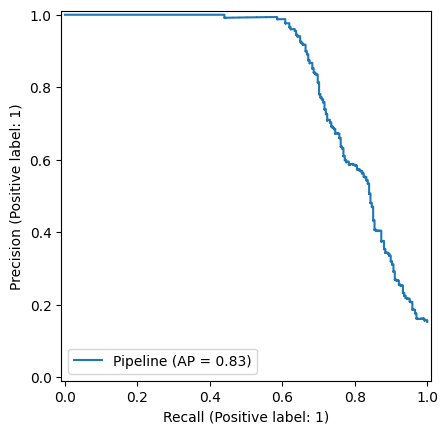

In [87]:
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test);

Посчитаем roc_auc на тестовой выборке:

In [88]:
y_proba = best_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
display(f"ROC AUC на тестовой выборке: {auc:.2f}")

'ROC AUC на тестовой выборке: 0.91'

Из classification_report выше - видно, что Accuracy = 0.94

Сравним с `DummyClassifier`:

In [89]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_clf.predict(X_test)
dummy_clf.score(X, y)

dummy_y_proba = dummy_clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, dummy_y_proba)
display(f"ROC AUC на тестовой выборке у DummyClassifier: {auc:.2f}")

'ROC AUC на тестовой выборке у DummyClassifier: 0.50'

## Анализ важности фичей

In [90]:
samples = 20
 
# Извлечение лучшей модели из результатов RandomizedSearchCV
best_model = search.best_estimator_.named_steps['models']

# Предобработка данных через пайплайн без конечной модели
preprocessor = search.best_estimator_.named_steps['preprocessor']
X_train_preprocessed = preprocessor.transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

all_feature_names = preprocessor.get_feature_names_out()

# Создаем DataFrame с соответствующими именами колонок
X_train_preprocessed_df = pd.DataFrame(X_train_preprocessed, 
                                       columns=all_feature_names)
X_test_preprocessed_df = pd.DataFrame(X_test_preprocessed, 
                                      columns=all_feature_names)

# Семпл данных для KernelExplainer
X_train_preprocessed_smpl = shap.sample(X_train_preprocessed_df, 
                                        samples, random_state=RANDOM_STATE)
X_test_preprocessed_smpl = shap.sample(X_test_preprocessed_df, 
                                       samples, random_state=RANDOM_STATE)

# Теперь, когда у нас есть DataFrame с именами признаков, мы можем использовать KernelExplainer
###explainer = shap.KernelExplainer(best_model.predict_proba, X_train_preprocessed_smpl)
explainer = shap.KernelExplainer(best_model.predict_proba, X_train_preprocessed_smpl)
shap_values = explainer.shap_values(X_test_preprocessed_smpl)

# Создаем объект Explanation для первого КЛАССА.
shap_values_explanation = shap.Explanation(
    values=shap_values[:,:,1], 
    base_values=explainer.expected_value,
    data=X_test_preprocessed_smpl,
    feature_names=all_feature_names
)

100%|██████████| 20/20 [00:04<00:00,  4.42it/s]


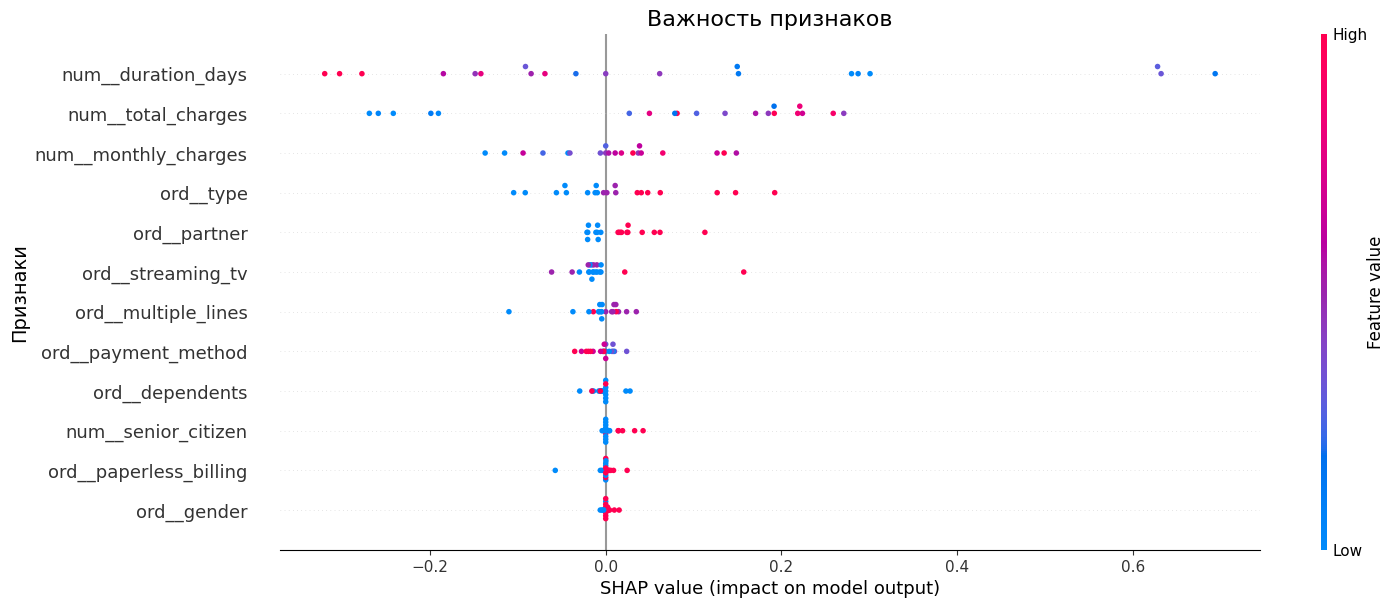

In [91]:
shap.summary_plot(shap_values_explanation, plot_size=[15, 6], show=False)
plt.ylabel("Признаки", fontsize=14)
plt.title("Важность признаков", fontsize=16)
plt.show()

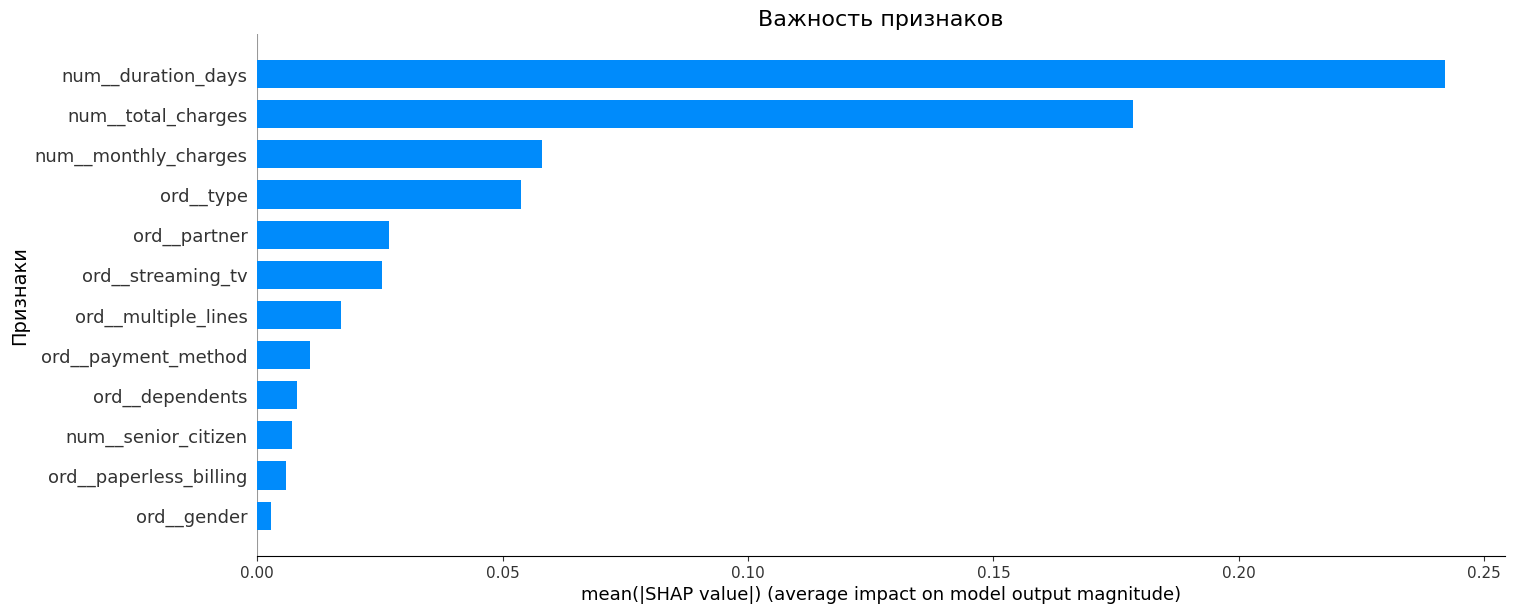

In [92]:
shap.summary_plot(shap_values_explanation, plot_size=[15,6], plot_type='bar', show=False)
plt.ylabel("Признаки", fontsize=14)
plt.title("Важность признаков", fontsize=16)
plt.show()

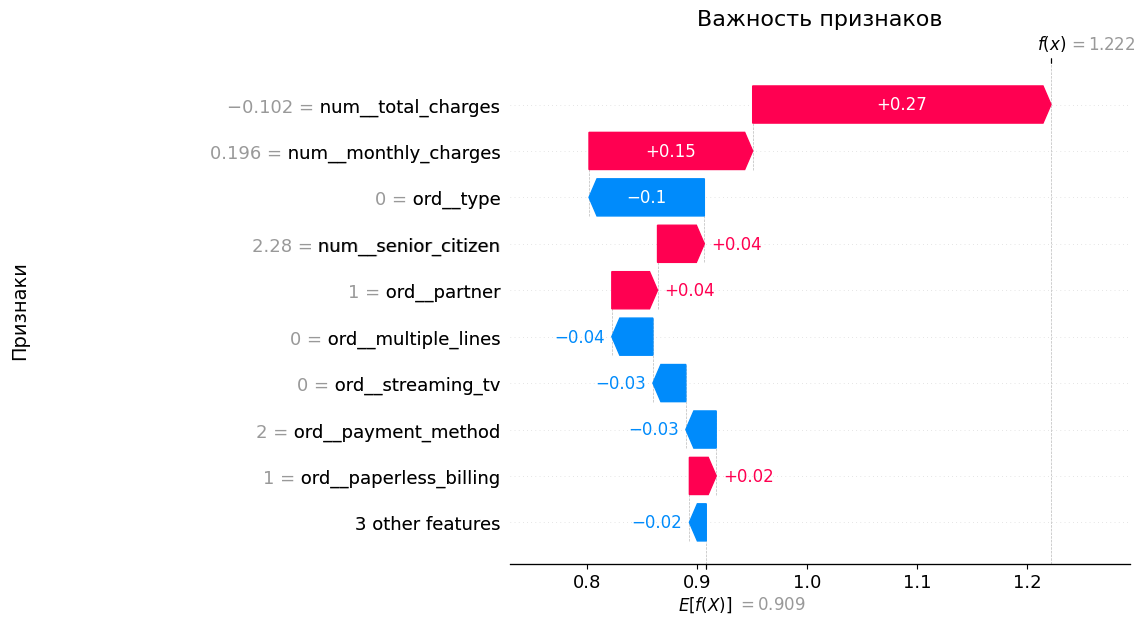

In [93]:
shap.plots.waterfall(shap_values_explanation[0], show=False)

plt.gcf().text(-0.5, 0.5, "Признаки", va="center", rotation="vertical", fontsize=14)
plt.title("Важность признаков", fontsize=16)
plt.show()

Вывод - наиболее важный признак модели catboost - это продолжительность контракта в днях. Хотя, phik посчитал лишь 0.37, что показывает малую корреляцию.

Посмотрим на график зависимости продолжительность контракта и целевого признаков:

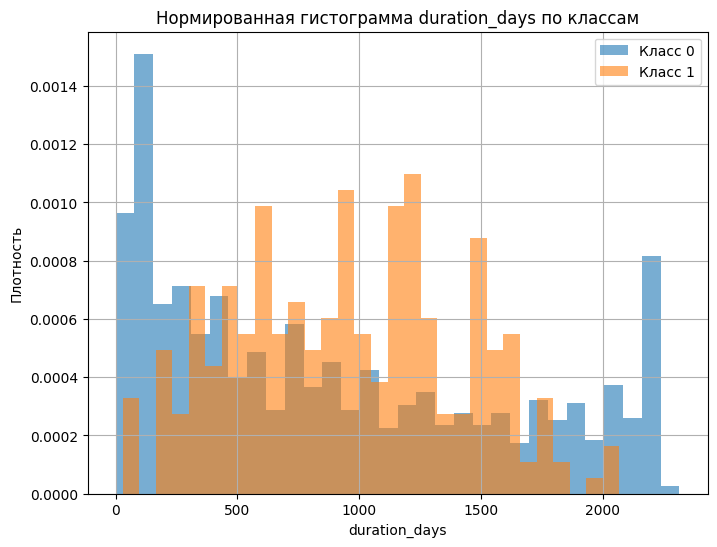

In [94]:
duration_class_0 = X_test[y_test == 0]['duration_days']
duration_class_1 = X_test[y_test == 1]['duration_days']

plt.figure(figsize=(8, 6))
plt.hist(duration_class_0, bins=30, alpha=0.6, density=True, label='Класс 0')
plt.hist(duration_class_1, bins=30, alpha=0.6, density=True, label='Класс 1')

plt.xlabel('duration_days')
plt.ylabel('Плотность')
plt.title('Нормированная гистограмма duration_days по классам')
plt.legend()
plt.grid(True)
plt.show()

График подтверждает отсутствие корреляции.

# Отчёт и выводы

## общие выводы

- В соответствии с поставленной задачей(см. первый раздел)
    - была проведена подготовка данных и их разведочный анализ, в результате которых:
        - были исправлены имена полей, исправлены типы данных, удалены малополезные признаки (в т. ч. с учётом мультиколлинеарности), заполнены пропуски
    - Был проведён разведочный анализ данных. Наиболее важные и потенциально полезные выводы из него:
        1. по графику распределения begin_date видно, что общее количество новых абонентов планомерно растёт - был пик в самом начале в 2014 году (возможно, активно привлекали клиентов в рамках стартового маркетинга). 
            1. При этом количество абонентов заключённых контрактов, завершившихся в дальнейшем расторжением - снижается год от года и приближается к (от сотни в квартал) к нулю. Это хороший знак.
        1. Медианный ежемесячный платёж ушедших пользователей 84, в то время как оставшихся - 69. Это говорит о том, что ушедшие были готовы платить больше (возможно, они более требовательны к качеству связи или чему-то ещё). 
    - была натренирована модель, предсказывающая расторжение контракта
        - выбрана наиболее оптимальная модель - **catboost**, показавшая наилучшие результаты:
            - качество предсказания на тестовой выборке: **ROC-AUC = 0.91 (Accuracy = 0.94)**
            - это удовлетворяет заданный критерий качества: ROC-AUC не менее 0.85.


## предлагаемые способы для дальнейшего улучшения модели 
- Для дальнейшего улучшения модели можно добавить больше признаков (из них могут выявиться более тонкие и точные закономерности - например, регион, возраст, занятость абонента), а также можно увеличить размер датасета (наверняка была взята лишь небольшая часть абонентов).

## предлагаемые бизнес-рекомендации заказчику
- использование данной модели может позволить сократить количество расторжений контракта - предлагается провести её тестовую эксплуатацию и принять окончательное решение о внедрении по итогам A\B-тестирования (на примере тестовой выборки мы могли бы **сократить отток абонентов на 67%**).
- чаще всего закрывают контракт, заключённый в феврале - в этот месяц стоит более активно удерживать абонентов
- у 70% абонентов есть дети, значит могут быть значительно востребованы продукты для детей